# Student Dropout Prediction - Notebook 01: EDA & Data Audit

## 1. Project Objective
**Business goal:** surface early warning signals of student dropout in Portuguese
higher education so institutions can intervene in time.
**Analytical goal:** understand a 3-class target (`Dropout` / `Enrolled` / `Graduate`)
and identify which features separate the groups.

**This notebook:** audit → clean → decode → explore → early engineering →
exploratory statistical tests → insights.

**Pipeline:** `01_eda_and_data_audit` → `02_feature_engineering` →
`03_statistical_analysis` → `04_modeling_and_evaluation`

## Setup & Importing Libraries

In [155]:
!pip install -q scikit-posthocs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', None)

## 2. Data Source
| Item | Detail |
|---|---|
| Dataset | *Predict students' dropout and academic success* |
| Repository | UCI Machine Learning Repository |
| Reference | Realinho et al., "Predicting Student Dropout and Academic Success" |
| Format | CSV, semicolon-separated |
| Size | 4,424 students × 36 features + 1 target |
| Origin | Aggregated administrative data, Portuguese higher education institutions |

## 3. Data Dictionary Summary
| Group | Variables |
|---|---|
| Demographics | Marital status, Nationality, Age at enrollment, Gender, Displaced, Educational special needs |
| Academic background | Application mode/order, Course, Daytime/evening attendance, Previous qualification (+grade), Admission grade |
| Family | Mother's/Father's qualification, Mother's/Father's occupation |
| Financial | Debtor, Tuition fees up to date, Scholarship holder, Unemployment rate, Inflation rate, GDP |
| 1st-year performance | Curricular units 1st/2nd sem: credited, enrolled, evaluations, approved, grade, without evaluations |
| Target | `Target`: Dropout / Enrolled / Graduate (at end of normal course duration) |

Full official codebook is the source of every mapping below (1:1).

## 4. Load Data

In [156]:
DATA_PATH = ('/content/drive/MyDrive/std_dropout_prediction_project/'
             'data/raw/predict_student_dropout_academic_success_raw.csv')

df = pd.read_csv(DATA_PATH, sep=';')
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded: 4424 rows × 37 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 5. Preserve Raw Copy

In [157]:
RAW = df.copy()

## 6. Column Name Inspection

In [158]:
print('Columns fixed by strip():', [repr(c) for c in RAW.columns if c != c.strip()])

df.columns = df.columns.str.strip()
print(df.columns.tolist())

Columns fixed by strip(): ["'Daytime/evening attendance\\t'"]
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unempl

In [159]:
# Renaming known typo safely
# The original dataset uses "Nacionality" instead of "Nationality"
if 'Nacionality' in df.columns and 'Nationality' not in df.columns:
    df = df.rename(columns={'Nacionality': 'Nationality'})
elif 'Nacionality' in df.columns and 'Nationality' in df.columns:
    print('Warning: Both Nacionality and Nationality exist. Inspect manually.')

## 7. Decode Categorical Variables

> **Note on Data Dictionary Modifications & Formatting**
>
> The mapping dictionaries defined below were constructed using the original data dictionary provided by the UCI Machine Learning Repository as the ground truth.
>
> While the original documentation was created with the intention of making Exploratory Data Analysis (EDA) easier—particularly for complex categorical variables like occupations and qualifications—it contained some formatting inconsistencies and verbose phrasing.
>
> **Key adjustments made for this notebook:**
> * **Improved Readability:** Slight phrasing adjustments were made to the string labels to make EDA outputs (such as charts, legends, and crosstabs) cleaner, more concise, and more intuitive to read.
> * **Formatting Fixes:** Corrected typographical errors and formatting issues present in the original UCI documentation.
> * **Semantic Integrity:** These modifications are strictly cosmetic. They are intended to improve clarity and professional presentation, **not** to alter the underlying data structure, mappings, or the original intent of the variables.
> * **Code Efficiency:** Variables with heavy overlap (e.g., `Father's` vs. `Mother's` qualifications and occupations) are handled by copying the base dictionary and using `.update()` for unique keys. This ensures strict consistency across related demographics and keeps the code DRY (Don't Repeat Yourself).

In [160]:
# Defining mapping dictionaries
marital_map = {
    1: "Single",
    2: "Married",
    3: "Widower",
    4: "Divorced",
    5: "De Facto Union",
    6: "Legally Separated"
}

gender_map = {
    0: "Female",
    1: "Male"
}

attendance_map = {
    0: "Evening",
    1: "Daytime"
}

yes_no_map = {
    0: "No",
    1: "Yes"
}

course_map = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (Evening Attendance)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equiniculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (Evening Attendance)"
}

nationality_map = {
    1: "Portuguese",
    2: "German",
    6: "Spanish",
    11: "Italian",
    13: "Dutch",
    14: "English",
    17: "Lithuanian",
    21: "Angolan",
    22: "Cape Verdean",
    24: "Guinean",
    25: "Mozambican",
    26: "Santomean",
    32: "Turkish",
    41: "Brazilian",
    62: "Romanian",
    100: "Moldova (Republic of)",
    101: "Mexican",
    103: "Ukrainian",
    105: "Russian",
    108: "Cuban",
    109: "Colombian"
}

application_mode_map = {
    1: "1st Phase - General Contingent",
    2: "Ordinance No. 612/93",
    5: "1st Phase - Special Contingent (Azores Island)",
    7: "Holders of Other Higher Courses",
    10: "Ordinance No. 854-B/99",
    15: "International Student (Bachelor)",
    16: "1st Phase - Special Contingent (Madeira Island)",
    17: "2nd Phase - General Contingent",
    18: "3rd Phase - General Contingent",
    26: "Ordinance No. 533-A/99, Item B2 (Different Plan)",
    27: "Ordinance No. 533-A/99, Item B3 (Other Institution)",
    39: "Over 23 Years Old",
    42: "Transfer",
    43: "Change of Course",
    44: "Technological Specialization Diploma Holders",
    51: "Change of Institution/Course",
    53: "Short Cycle Diploma Holders",
    57: "Change of Institution/Course (International)"
}

prev_qualification_map = {
    1: "Secondary Education",
    2: "Higher Education - Bachelor's Degree",
    3: "Higher Education - Degree",
    4: "Higher Education - Master's Degree",
    5: "Higher Education - Doctorate",
    6: "Frequency of Higher Education",
    9: "12th Year of Schooling - Not Completed",
    10: "11th Year of Schooling - Not Completed",
    12: "Other - 11th Year of Schooling",
    14: "10th Year of Schooling",
    15: "10th Year of Schooling - Not Completed",
    19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent",
    38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equivalent",
    39: "Technological Specialization Course",
    40: "Higher Education - Degree (1st Cycle)",
    42: "Professional Higher Technical Course",
    43: "Higher Education - Master (2nd Cycle)"
}

mother_qualification_map = {
    1: "Secondary Education - 12th Year of Schooling or Equivalent",
    2: "Higher Education - Bachelor's Degree",
    3: "Higher Education - Degree",
    4: "Higher Education - Master's",
    5: "Higher Education - Doctorate",
    6: "Frequency of Higher Education",
    9: "12th Year of Schooling - Not Completed",
    10: "11th Year of Schooling - Not Completed",
    11: "7th Year (Old)",
    12: "Other - 11th Year of Schooling",
    14: "10th Year of Schooling",
    18: "General Commerce Course",
    19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent",
    22: "Technical-Professional Course",
    26: "7th Year of Schooling",
    27: "2nd Cycle of General High School",
    29: "9th Year of Schooling - Not Completed",
    30: "8th Year of Schooling",
    34: "Unknown",
    35: "Can't Read or Write",
    36: "Can Read Without 4th Year of Schooling",
    37: "Basic Education 1st Cycle (4th/5th Year) or Equivalent",
    38: "Basic Education 2nd Cycle",
    39: "Technological Specialization Course",
    40: "Higher Education - Degree (1st Cycle)",
    41: "Specialized Higher Studies Course",
    42: "Professional Higher Technical Course",
    43: "Higher Education - Master (2nd Cycle)",
    44: "Higher Education - Doctorate (3rd Cycle)"
}

# Father's qualifications inherits from Mother's, adding unique Father keys
father_qualification_map = mother_qualification_map.copy()
father_qualification_map.update({
    13: "2nd Year Complementary High School",
    20: "Complementary High School Course",
    25: "Complementary High School - Not Concluded",
    31: "General Course of Administration and Commerce",
    33: "Supplementary Accounting and Administration"
})

mother_occupation_map = {
    0: "Student",
    1: "Legislative/Executive Directors & Managers",
    2: "Intellectual & Scientific Specialists",
    3: "Intermediate Level Technicians & Professions",
    4: "Administrative Staff",
    5: "Personal Services, Security, & Sellers",
    6: "Farmers & Skilled Agriculture, Fisheries, & Forestry",
    7: "Skilled Industry, Construction, & Craftsmen",
    8: "Machine Operators & Assembly Workers",
    9: "Unskilled Workers",
    10: "Armed Forces Professions",
    90: "Other Situation",
    99: "Not Reported (Blank)",
    122: "Health Professionals",
    123: "Teachers",
    125: "ICT Specialists",
    131: "Intermediate Science & Engineering Technicians",
    132: "Intermediate Health Technicians & Professionals",
    134: "Intermediate Legal, Social, & Cultural Technicians",
    141: "Office Workers & Secretaries",
    143: "Data, Accounting, & Financial Operators",
    144: "Other Administrative Support Staff",
    151: "Personal Service Workers",
    152: "Sellers",
    153: "Personal Care Workers",
    171: "Skilled Construction Workers",
    173: "Skilled Printing, Jewelers, & Artisans",
    175: "Food Processing, Woodworking, & Clothing Workers",
    191: "Cleaning Workers",
    192: "Unskilled Agriculture, Animal, Fisheries, & Forestry",
    193: "Unskilled Extractive, Construction, & Transport Workers",
    194: "Meal Preparation Assistants"
}

# Father's occupations inherits from Mother's, adding unique Father keys
father_occupation_map = mother_occupation_map.copy()
father_occupation_map.update({
    101: "Armed Forces Officers",
    102: "Armed Forces Sergeants",
    103: "Other Armed Forces Personnel",
    112: "Directors of Administrative & Commercial Services",
    114: "Hotel, Catering, Trade, & Services Directors",
    121: "Physical Sciences, Math, & Engineering Specialists",
    124: "Finance, Accounting, & PR Specialists",
    135: "ICT Technicians",
    154: "Protection & Security Services Personnel",
    161: "Market-Oriented Farmers & Agricultural Workers",
    163: "Subsistence Farmers, Fishermen, & Hunters",
    172: "Skilled Metallurgy & Metalworking Workers",
    174: "Skilled Electricity & Electronics Workers",
    181: "Fixed Plant & Machine Operators",
    182: "Assembly Workers",
    183: "Vehicle Drivers & Mobile Equipment Operators",
    195: "Street Vendors & Service Providers"
})

In [161]:
# Convert coded columns to nullable integer (protects mapping if NaNs ever appear)
coded_columns = ['Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nationality',
    "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

for col in coded_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    else:
        print(f'Warning: column not found: {col}')

In [162]:
STRICT = False
mapping_report = []

def decode_column(data, col, mapping, out_col=None, strict=True,
                  unknown_label='UNMAPPED - CHECK'):
    """Map codes to labels while auditing unmapped values and null creation."""
    if out_col is None:
        out_col = col
    if col not in data.columns:
        print(f'⚠️ Column not found: {col}')
        mapping_report.append({'column': col, 'status': 'column missing',
                               'unmapped': [], 'nulls_before': None, 'nulls_after': None})
        return data

    s = data[col]
    nulls_before = int(s.isna().sum())
    unmapped = sorted(set(s.dropna().unique()) - set(mapping.keys()), key=str)
    record = {'column': col, 'status': 'ok', 'unmapped': unmapped,
              'nulls_before': nulls_before, 'nulls_after': None}

    if unmapped:
        print(f'❌ {col} has unmapped values: {unmapped}')
        if strict:
            mapping_report.append(record)
            raise ValueError(f'Fix mapping for {col} or handle unmapped values explicitly.')

    mapped = s.map(mapping)
    if (not strict) and unmapped:
        mapped = mapped.copy()
        mapped[s.notna() & ~s.isin(mapping.keys())] = unknown_label

    data[out_col] = mapped
    record['nulls_after'] = int(data[out_col].isna().sum())
    mapping_report.append(record)
    print(f'✅ Decoded {col}. Nulls after: {record["nulls_after"]}')
    return data

In [163]:
df = decode_column(df, 'Marital status', marital_map, strict=STRICT)
df = decode_column(df, 'Gender', gender_map, strict=STRICT)
df = decode_column(df, 'Daytime/evening attendance', attendance_map, strict=STRICT)

for col in ['Displaced', 'Educational special needs', 'Debtor',
            'Tuition fees up to date', 'Scholarship holder', 'International']:
    df = decode_column(df, col, yes_no_map, strict=STRICT)

df = decode_column(df, 'Course', course_map, strict=STRICT)
df = decode_column(df, 'Nationality', nationality_map, strict=STRICT)
df = decode_column(df, 'Application mode', application_mode_map, strict=STRICT)
df = decode_column(df, 'Previous qualification', prev_qualification_map, strict=STRICT)
df = decode_column(df, "Mother's qualification", mother_qualification_map, strict=STRICT)
df = decode_column(df, "Father's qualification", father_qualification_map, strict=STRICT)
df = decode_column(df, "Mother's occupation", mother_occupation_map, strict=STRICT)
df = decode_column(df, "Father's occupation", father_occupation_map, strict=STRICT)

✅ Decoded Marital status. Nulls after: 0
✅ Decoded Gender. Nulls after: 0
✅ Decoded Daytime/evening attendance. Nulls after: 0
✅ Decoded Displaced. Nulls after: 0
✅ Decoded Educational special needs. Nulls after: 0
✅ Decoded Debtor. Nulls after: 0
✅ Decoded Tuition fees up to date. Nulls after: 0
✅ Decoded Scholarship holder. Nulls after: 0
✅ Decoded International. Nulls after: 0
✅ Decoded Course. Nulls after: 0
✅ Decoded Nationality. Nulls after: 0
✅ Decoded Application mode. Nulls after: 0
✅ Decoded Previous qualification. Nulls after: 0
✅ Decoded Mother's qualification. Nulls after: 0
✅ Decoded Father's qualification. Nulls after: 0
✅ Decoded Mother's occupation. Nulls after: 0
✅ Decoded Father's occupation. Nulls after: 0


In [164]:
# Target validation
print(df['Target'].value_counts(dropna=False))
print(df['Target'].value_counts(normalize=True).round(4))

expected = ['Dropout', 'Enrolled', 'Graduate']
if set(df['Target'].dropna()) == set(expected):
    df['Target'] = pd.Categorical(df['Target'], categories=expected)
    print('Target categories:', df['Target'].cat.categories.tolist())
else:
    print('⚠️ Unexpected target labels — inspect before continuing.')

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    0.4993
Dropout     0.3212
Enrolled    0.1795
Name: proportion, dtype: float64
Target categories: ['Dropout', 'Enrolled', 'Graduate']


## 8. Mapping Audit

In [165]:
mapping_report_df = pd.DataFrame(mapping_report)
display(mapping_report_df)

problems = mapping_report_df[mapping_report_df['unmapped'].apply(len) > 0]
print('Columns with unmapped values:', len(problems))

,column,status,unmapped,nulls_before,nulls_after
0,Marital status,ok,[],0,0
1,Gender,ok,[],0,0
2,Daytime/evening attendance,ok,[],0,0
3,Displaced,ok,[],0,0
4,Educational special needs,ok,[],0,0
5,Debtor,ok,[],0,0
6,Tuition fees up to date,ok,[],0,0
7,Scholarship holder,ok,[],0,0
8,International,ok,[],0,0
9,Course,ok,[],0,0


Columns with unmapped values: 0


In [166]:
# Did decoding create missing values?
null_audit = pd.concat([RAW.isna().sum(), df.isna().sum()], axis=1)
null_audit.columns = ['null_before', 'null_after']
display(null_audit[null_audit['null_after'] > 0])
print('✅ No new missing values introduced.' if null_audit['null_after'].sum() == 0
      else '⚠️ Investigate above.')

RAW.head(10)
df.head(10)

,null_before,null_after


✅ No new missing values introduced.


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Single,2nd Phase - General Contingent,5,Animation and Multimedia Design,Daytime,Secondary Education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,"Personal Services, Security, & Sellers",Unskilled Workers,127.3,Yes,No,No,Yes,Male,No,20,No,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International Student (Bachelor),1,Tourism,Daytime,Secondary Education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,Intermediate Level Technicians & Professions,Intermediate Level Technicians & Professions,142.5,Yes,No,No,No,Male,No,19,No,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1st Phase - General Contingent,5,Communication Design,Daytime,Secondary Education,122.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,Unskilled Workers,Unskilled Workers,124.8,Yes,No,No,No,Male,No,19,No,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,2nd Phase - General Contingent,2,Journalism and Communication,Daytime,Secondary Education,122.0,Portuguese,Basic Education 2nd Cycle,Basic Education 1st Cycle (4th/5th Year) or Eq...,"Personal Services, Security, & Sellers",Intermediate Level Technicians & Professions,119.6,Yes,No,No,Yes,Female,No,20,No,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 Years Old,1,Social Service (Evening Attendance),Evening,Secondary Education,100.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 2nd Cycle,Unskilled Workers,Unskilled Workers,141.5,No,No,No,Yes,Female,No,45,No,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,Married,Over 23 Years Old,1,Management (Evening Attendance),Evening,Basic Education 3rd Cycle (9th/10th/11th Year)...,133.1,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,Unskilled Workers,"Skilled Industry, Construction, & Craftsmen",114.8,No,No,Yes,Yes,Male,No,50,No,0,5,10,5,11.857143,0,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,Single,1st Phase - General Contingent,1,Nursing,Daytime,Secondary Education,142.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Basic Education 2nd Cycle,"Skilled Industry, Construction, & Craftsmen",Armed Forces Professions,128.4,Yes,No,No,Yes,Female,Yes,18,No,0,7,9,7,13.300000,0,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,Single,3rd Phase - General Contingent,4,Tourism,Daytime,Secondary Education,119.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,Unskilled Workers,Unskilled Workers,113.1,Yes,No,No,No,Male,No,22,No,0,5,5,0,0.000000,0,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,Single,1st Phase - General Contingent,3,Social Service,Daytime,Secondary Education,137.0,Romanian,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,Unskilled Workers,Unskilled Workers,129.3,No,No,No,Yes,Female,Yes,21,Yes,0,6,8,6,13.875000,0,0,6,7,6,14.

* No values were found in the data that were missing from their mapping dictionaries.
* No columns gained missing values after decoding.

## 9. Missing Value & Duplicate Audit

In [167]:
missing = df.isna().sum()
print('Missing values:', missing.sum())
if missing.sum() > 0:
    display(missing[missing > 0])

duplicates = df.duplicated().sum()
print('Duplicate rows:', duplicates)
if duplicates > 0:
    display(df[df.duplicated(keep=False)].head(20))

Missing values: 0
Duplicate rows: 0


* No missing values. No duplicate rows.

## 10. Numeric Range Checks

In [168]:
range_specs = [
    ('Previous qualification (grade)', 0, 200),
    ('Admission grade', 0, 200),
    ('Curricular units 1st sem (grade)', 0, 20),
    ('Curricular units 2nd sem (grade)', 0, 20),
    ('Age at enrollment', 15, 90),
]
for col, lo, hi in range_specs:
    s = pd.to_numeric(df[col], errors='coerce')
    print(f'{col}: out-of-range = {int(((s < lo) | (s > hi)).sum())}, missing = {int(s.isna().sum())}')

print()
for col in [c for c in df.columns if c.startswith('Curricular units') and '(grade)' not in c]:
    s = pd.to_numeric(df[col], errors='coerce')
    print(f'{col}: negative = {int((s < 0).sum())}, missing = {int(s.isna().sum())}')

Previous qualification (grade): out-of-range = 0, missing = 0
Admission grade: out-of-range = 0, missing = 0
Curricular units 1st sem (grade): out-of-range = 0, missing = 0
Curricular units 2nd sem (grade): out-of-range = 0, missing = 0
Age at enrollment: out-of-range = 0, missing = 0

Curricular units 1st sem (credited): negative = 0, missing = 0
Curricular units 1st sem (enrolled): negative = 0, missing = 0
Curricular units 1st sem (evaluations): negative = 0, missing = 0
Curricular units 1st sem (approved): negative = 0, missing = 0
Curricular units 1st sem (without evaluations): negative = 0, missing = 0
Curricular units 2nd sem (credited): negative = 0, missing = 0
Curricular units 2nd sem (enrolled): negative = 0, missing = 0
Curricular units 2nd sem (evaluations): negative = 0, missing = 0
Curricular units 2nd sem (approved): negative = 0, missing = 0
Curricular units 2nd sem (without evaluations): negative = 0, missing = 0


* All grades, ages and unit counts fall within official ranges. No invalid values.

## 11. Logical Consistency Checks

In [169]:
# (a) Approved units must not exceed enrolled units
for sem in ['1st', '2nd']:
    approved = pd.to_numeric(df[f'Curricular units {sem} sem (approved)'], errors='coerce')
    enrolled = pd.to_numeric(df[f'Curricular units {sem} sem (enrolled)'], errors='coerce')
    print(f'{sem} semester: approved > enrolled count = {int((approved > enrolled).sum())}')

# (b) Debtor vs tuition fees
display(pd.crosstab(df['Debtor'], df['Tuition fees up to date'], dropna=False))

# (c) International vs nationality
display(pd.crosstab(df['Nationality'], df['International'], dropna=False))

# (d) International vs application mode
display(pd.crosstab(df['Application mode'], df['International'], dropna=False))

1st semester: approved > enrolled count = 0
2nd semester: approved > enrolled count = 0


Tuition fees up to date,No,Yes
Debtor,,
No,282,3639
Yes,246,257


International,No,Yes
Nationality,,
Angolan,0,2
Brazilian,0,38
Cape Verdean,0,13
Colombian,0,1
Cuban,0,1
Dutch,0,1
English,0,1
German,0,2
Guinean,0,5


International,No,Yes
Application mode,,
1st Phase - General Contingent,1679,29
1st Phase - Special Contingent (Azores Island),16,0
1st Phase - Special Contingent (Madeira Island),38,0
2nd Phase - General Contingent,862,10
3rd Phase - General Contingent,121,3
Change of Course,298,14
Change of Institution/Course,59,0
Change of Institution/Course (International),0,1
Holders of Other Higher Courses,138,1


* Approved ≤ enrolled holds for every student in both semesters.
* 257 students are `Debtor = Yes` yet `Tuition fees up to date = Yes` → the two
  variables capture different concepts (past arrears vs current status). Keep both.
* `International` aligns perfectly with non-Portuguese nationality → redundant pair;
  consider dropping one in Notebook 02.

In [170]:
def safe_ratio(data, num_col, den_col, new_col):
    num = pd.to_numeric(data[num_col], errors='coerce')
    den = pd.to_numeric(data[den_col], errors='coerce')
    data[new_col] = np.where(den > 0, num / den, np.nan)
    return data

for sem in ['1st', '2nd']:
    df = safe_ratio(df, f'Curricular units {sem} sem (approved)',
                    f'Curricular units {sem} sem (enrolled)', f'Approved ratio {sem} sem')

df['Approval ratio change'] = (df['Approved ratio 2nd sem'] - df['Approved ratio 1st sem'])
df['Total approved first year'] = (
    pd.to_numeric(df['Curricular units 1st sem (approved)'], errors='coerce') +
    pd.to_numeric(df['Curricular units 2nd sem (approved)'], errors='coerce'))

print(df[['Approved ratio 1st sem', 'Approved ratio 2nd sem']].describe().round(3))
print('Missing ratios:', df['Approved ratio 1st sem'].isna().sum())

       Approved ratio 1st sem  Approved ratio 2nd sem
count                4244.000                4244.000
mean                    0.727                   0.688
std                     0.343                   0.366
min                     0.000                   0.000
25%                     0.600                   0.500
50%                     0.857                   0.833
75%                     1.000                   1.000
max                     1.000                   1.000
Missing ratios: 180


## 12. Univariate & Bivariate Exploration

In [171]:
print("- Numerical Features Summary -")
display(df.describe())
print("- Categorical Features Summary -")
display(df.describe(include=['object', 'category']))

X_num = df.select_dtypes(include=[np.number]).columns.drop('Target', errors='ignore')
X_cat = df.select_dtypes(exclude=[np.number]).columns.drop('Target', errors='ignore')
print(f"Numerical: {len(X_num)} | Categorical: {len(X_cat)}")

- Numerical Features Summary -


,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Approved ratio 1st sem,Approved ratio 2nd sem,Approval ratio change,Total approved first year
count,4424.0,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4244.000000,4244.000000,4244.000000,4424.000000
mean,1.727848,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,0.727484,0.688364,-0.039121,9.142405
std,1.313793,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,0.342821,0.365513,0.193261,5.960612
min,0.0,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000,0.000000,-1.000000,0.000000
25%,1.0,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,0.600000,0.500000,-0.083479,5.000000
50%,1.0,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,0.857143,0.833333,0.000000,10.000000
75%,2.0,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,1.000000,1.000000,0.000000,12.000000
max,9.0,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,1.000000,1.000000,1.000000,43.000000


- Categorical Features Summary -


,Marital status,Application mode,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International,Target
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,18,17,2,17,21,29,34,32,46,2,2,2,2,2,2,2,3
top,Single,1st Phase - General Contingent,Nursing,Daytime,Secondary Education,Portuguese,Secondary Education - 12th Year of Schooling o...,Basic Education 1st Cycle (4th/5th Year) or Eq...,Unskilled Workers,Unskilled Workers,Yes,No,No,Yes,Female,No,No,Graduate
freq,3919,1708,766,3941,3717,4314,1069,1209,1577,1010,2426,4373,3921,3896,2868,3325,4314,2209


Numerical: 23 | Categorical: 17


# Numerical Features Summary

## General Profile
- **Age at enrollment**: Median = 20 years; most between 19–25, with rare outliers up to 70.
- **Admission & previous grades**: Centered around 125–127 (scale 95–190).
- **Application order**: Majority applied in 1st or 2nd order (mean ≈ 1.7).

## Academic Performance
- **Semester enrollment**: Typically 6–7 courses per semester.
- **Evaluations**: Median ≈ 8 per semester.
- **Approvals**: Median ≈ 5 courses passed per semester.
- **Grades**: Median ≈ 12/20, showing moderate achievement.
- **Credits/without evaluations**: Mostly 0, meaning few exemptions or skipped courses.

## Approval Ratios
- **1st semester**: Mean ≈ 0.73 (73% success rate).
- **2nd semester**: Mean ≈ 0.69 (69% success rate).
- **Change**: Slight decline (≈ –0.04 on average).
- **Total approved first year**: Median = 10 courses, mean ≈ 9.1, max = 43.

## Economic Indicators
- **Unemployment rate**: Mean ≈ 11.6%.
- **Inflation rate**: Mean ≈ 1.2%.
- **GDP growth**: Mean ≈ 0.002 (low variation).

## Special Cases
- **No enrollment both semesters**: Rare (≈ 4% of students).
- **Outliers**: Some students with unusually high course loads or older ages.

---

### 📝 Summary Note
Typical students are \~20 years old, admitted with grades around 127, enrolling in 6–7 courses per semester, passing about 5, and earning grades near 12/20. Approval ratios are fairly strong (~70%), but performance tends to dip slightly in the second semester. Most complete around 10 courses in their first year, though outcomes vary widely, with some excelling and a few not enrolling at all.


### Detailed Breakdown of Categorical Feature Distributions

To ensure no information is missed, here is a detailed breakdown showing all unique values and their exact percentages for each categorical feature:

In [172]:
print('--- Full Value Counts for Categorical Features ---')
for col in X_cat:
    print(f'\n--- {col} ---')
    # Displaying value counts and normalized percentages for all unique categories
    display(pd.DataFrame({
        'Count': df[col].value_counts(),
        'Percentage': df[col].value_counts(normalize=True).mul(100).round(2)
    }).sort_index())


--- Full Value Counts for Categorical Features ---

--- Marital status ---


,Count,Percentage
Marital status,,
De Facto Union,25,0.57
Divorced,91,2.06
Legally Separated,6,0.14
Married,379,8.57
Single,3919,88.58
Widower,4,0.09



--- Application mode ---


,Count,Percentage
Application mode,,
1st Phase - General Contingent,1708,38.61
1st Phase - Special Contingent (Azores Island),16,0.36
1st Phase - Special Contingent (Madeira Island),38,0.86
2nd Phase - General Contingent,872,19.71
3rd Phase - General Contingent,124,2.80
Change of Course,312,7.05
Change of Institution/Course,59,1.33
Change of Institution/Course (International),1,0.02
Holders of Other Higher Courses,139,3.14



--- Course ---


...

,Count,Percentage
Gender,,
Female,2868,64.83
Male,1556,35.17



--- Scholarship holder ---


,Count,Percentage
Scholarship holder,,
No,3325,75.16
Yes,1099,24.84



--- International ---


,Count,Percentage
International,,
No,4314,97.51
Yes,110,2.49


### 💡 Key Insights from Descriptive Statistics

**1. Target Variable Distribution**
* The outcome is moderately imbalanced: **Graduate (49.9%)**, **Dropout (32.1%)**, and **Enrolled (17.9%)**.
* *Action:* We will need stratified train/test splits and should monitor precision/recall for the minority classes during modeling.

**2. Student Demographics**
* **Homogeneous & Local:** Approximately 97.5% (4314/4424) are Portuguese, confirming a non-international, predominantly Single (~89%, 3919/4424) student body.
* **Gender Skew:** ~65% (2868/4424) Female, likely driven by high enrollment in specific courses (e.g., Nursing, Social Services).
* **Age Outliers:** Median age is 20 (traditional students), but the maximum age is 70. *Insight:* We have a distinct sub-population of mature learners whose dropout drivers may differ from traditional students.
* **Displaced Status:** ~55% (2426/4424) of students relocated for studies, introducing potential housing, financial, and social isolation stressors.

**3. Academic Performance Signals**
* **The "Passing" Threshold Skew:** Mean semester grades (~10.6 in 1st sem and ~10.2 in 2nd sem out of 20) sit just above the passing grade of 10, but medians are higher (12.28 in 1st sem and 12.20 in 2nd sem). This left-skew implies a distinct group of students are scoring near zero (failing/abandoning), heavily dragging down the mean.
* **Workload Attrition:** Students typically enroll in 6.27 units in the 1st semester and 6.23 units in the 2nd semester, but the average *approved* units drop from 4.70 (1st sem) to 4.43 (2nd sem), suggesting 2nd-semester difficulty or early dropouts reducing their course loads.

**4. Socioeconomic & Financial Vulnerability**
* **Working-Class Backgrounds:** Top parental occupations are "Unskilled Workers" and intermediate technicians.
* **Financial Tightropes:** While \~88% (3896/4424) pay tuition on time and \~89% (3921/4424) are not debtors, only **~25% (1099/4424) hold scholarships**. This implies a heavy reliance on family income or external employment, making these students highly sensitive to economic shocks.

**5. Macro-Economic Context (Cohort Proxies)**
* The dataset captures significant economic volatility: **Unemployment** spans 7.6% to 16.2%, **Inflation** ranges from -0.8% to 3.7%, and **GDP** ranges from -4.06% to 3.51%.
* *Action:* These are not individual features but cohort/year proxies. They must be handled carefully in Notebook 04 to avoid time-based data leakage during cross-validation.

**6. Data Quality**
* **Pristine Data:** 0 missing values, 0 duplicates, and all numerical ranges align perfectly with the official data dictionary. No imputation is required.

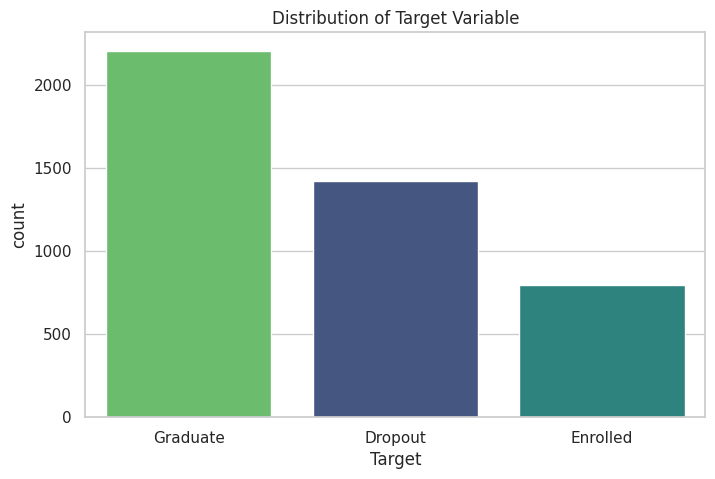

Target
Graduate    0.4993
Dropout     0.3212
Enrolled    0.1795
Name: proportion, dtype: float64


In [173]:
# Target distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target', palette='viridis',
              order=df['Target'].value_counts().index, hue='Target', legend=False)
plt.title('Distribution of Target Variable')
plt.show()
print(df['Target'].value_counts(normalize=True).round(4))

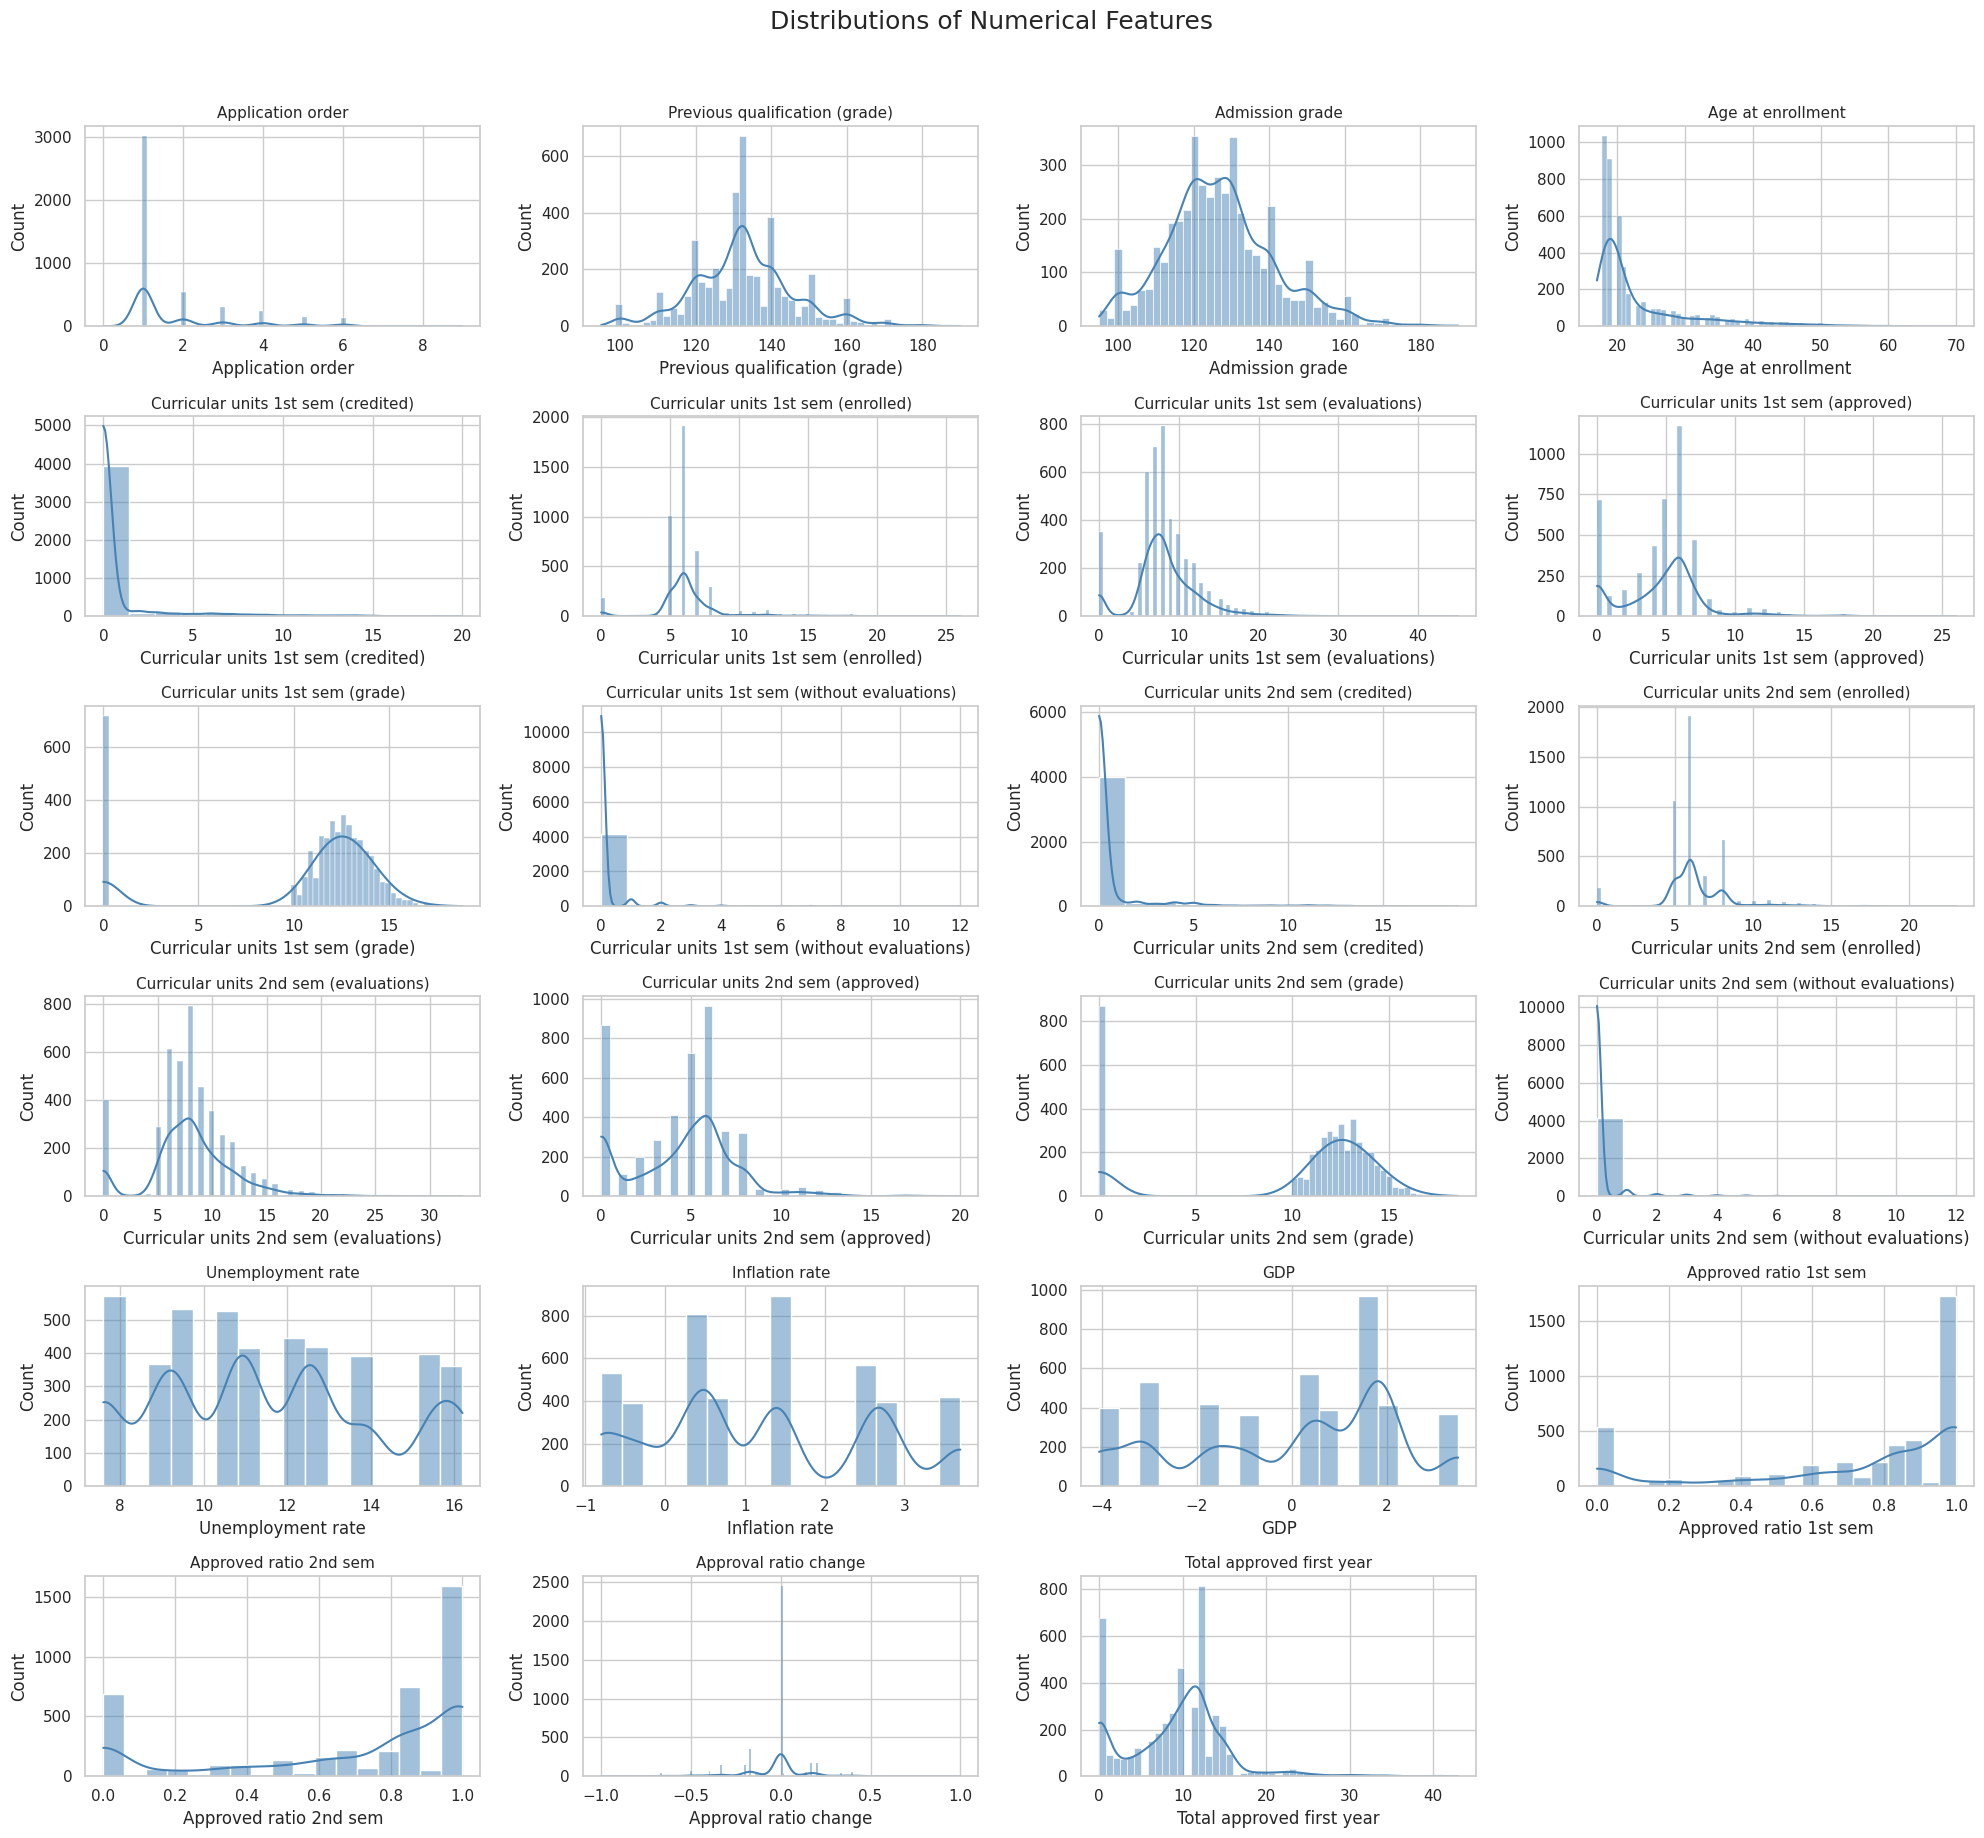

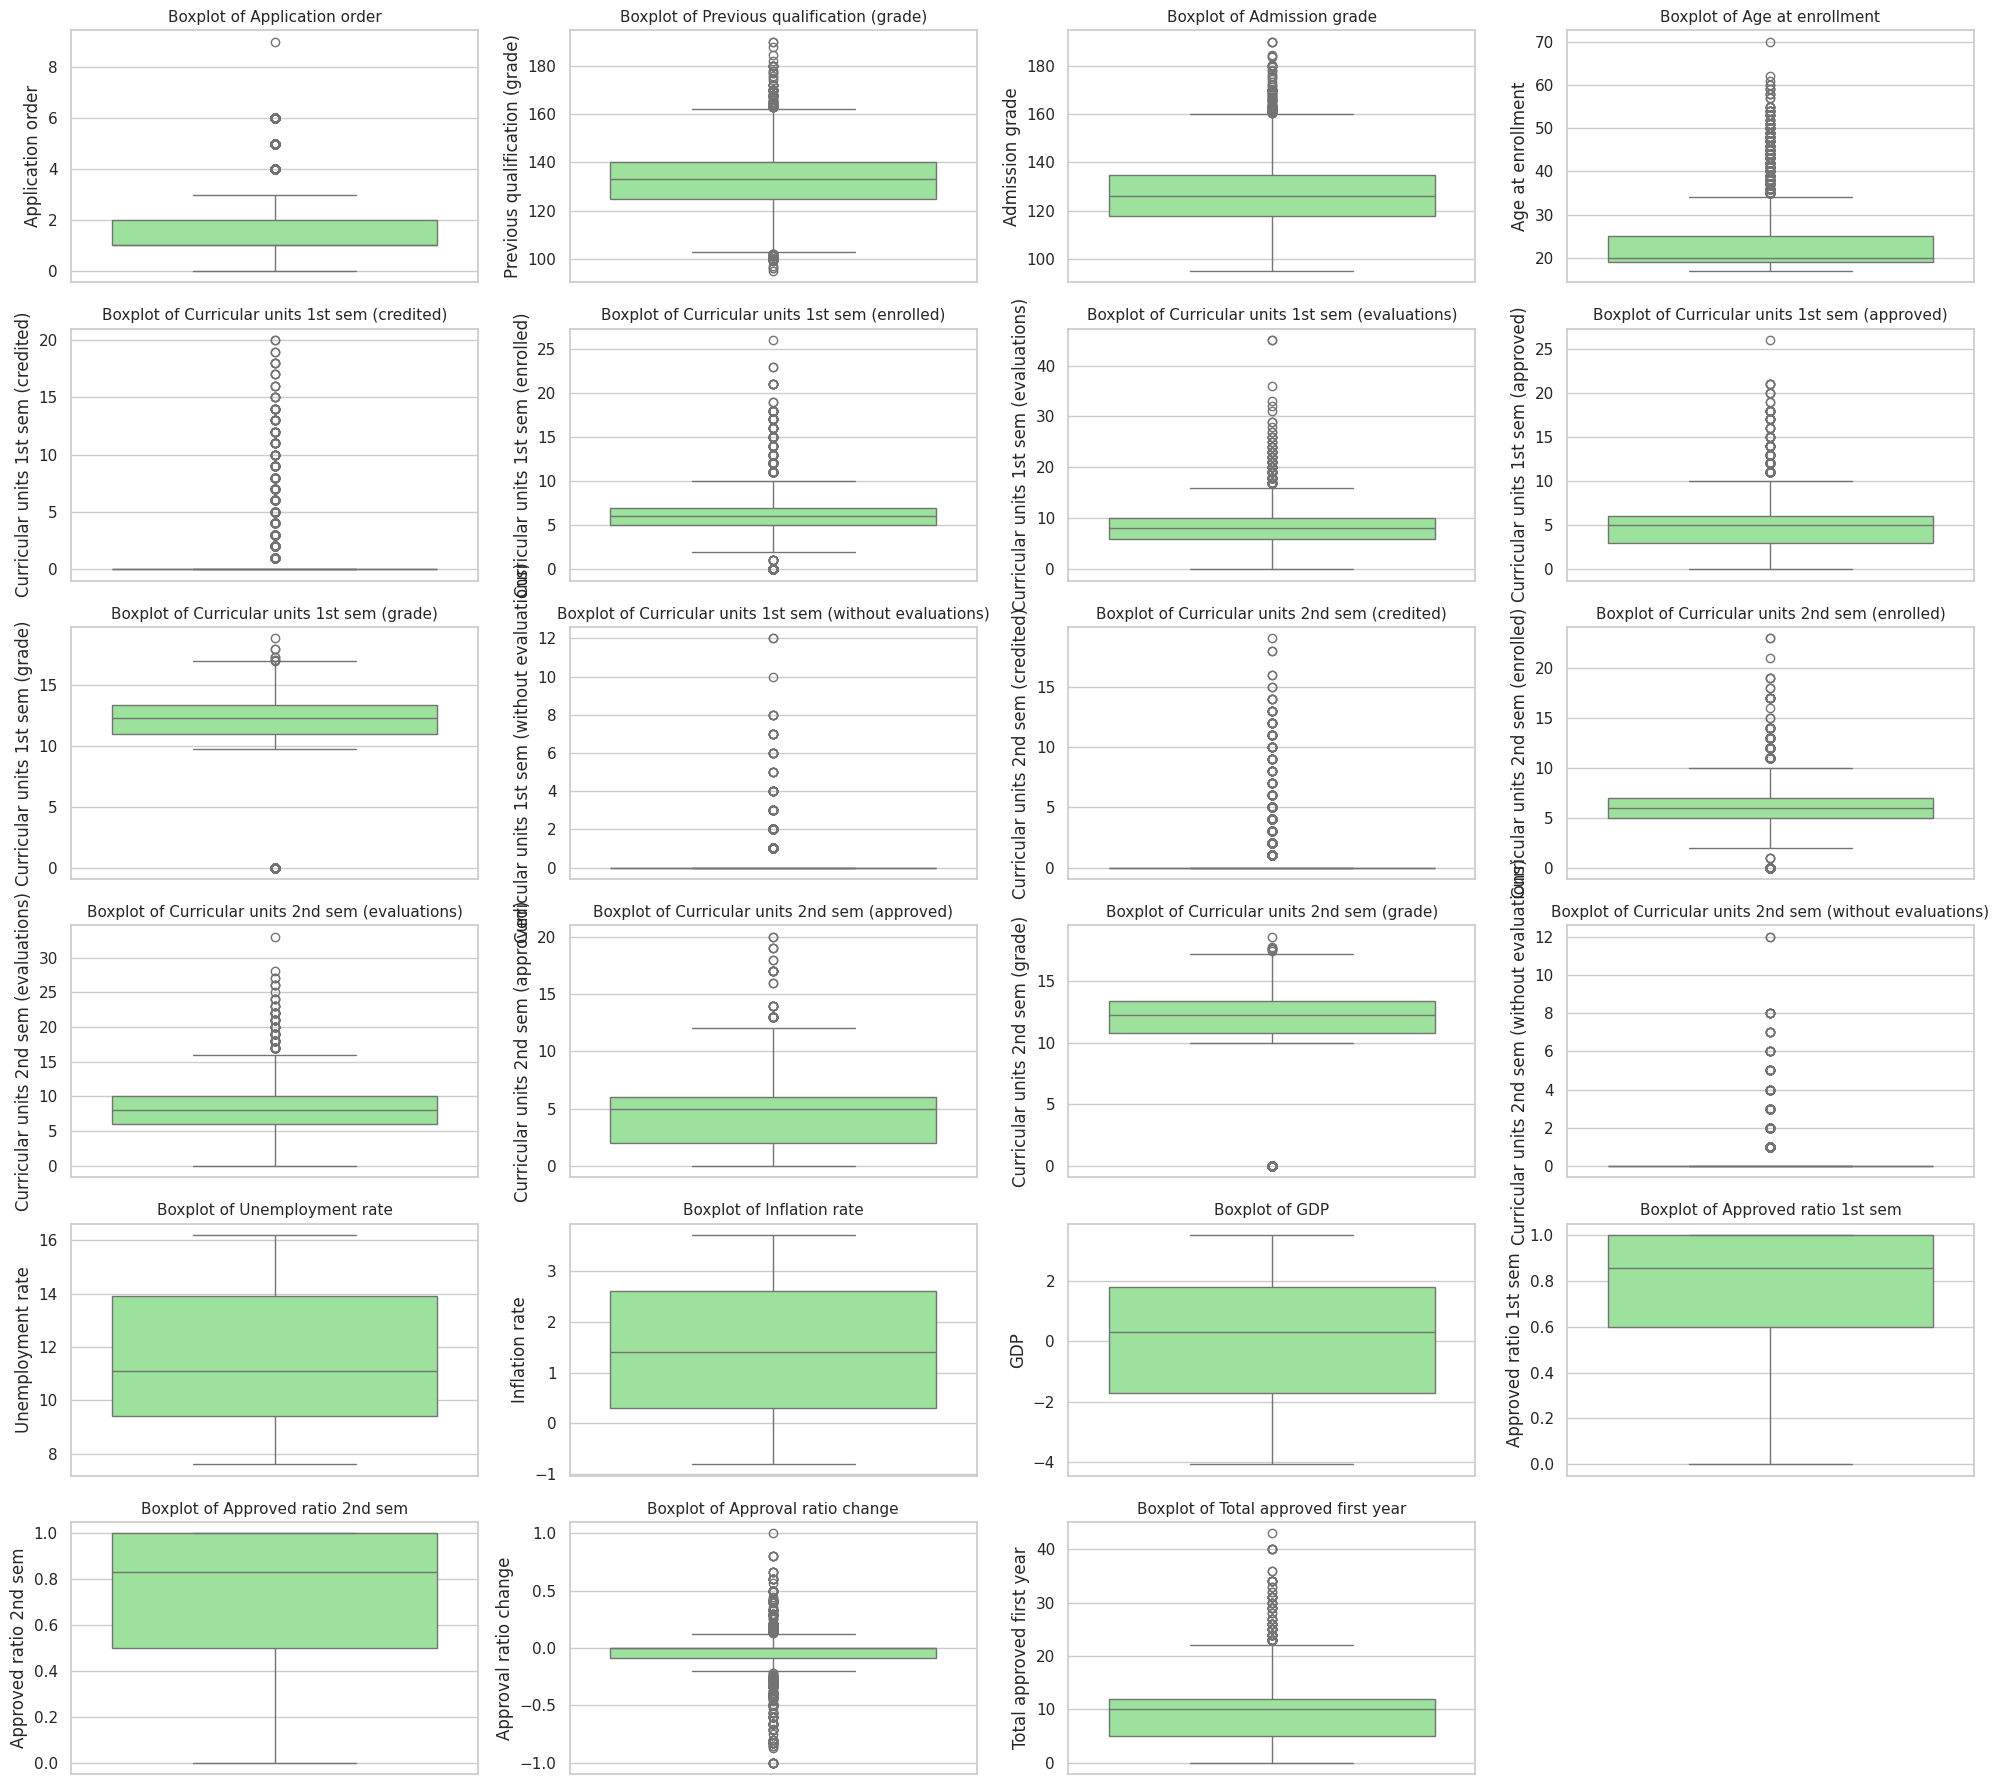

/tmp/ipykernel_2392/3469668062.py:47: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


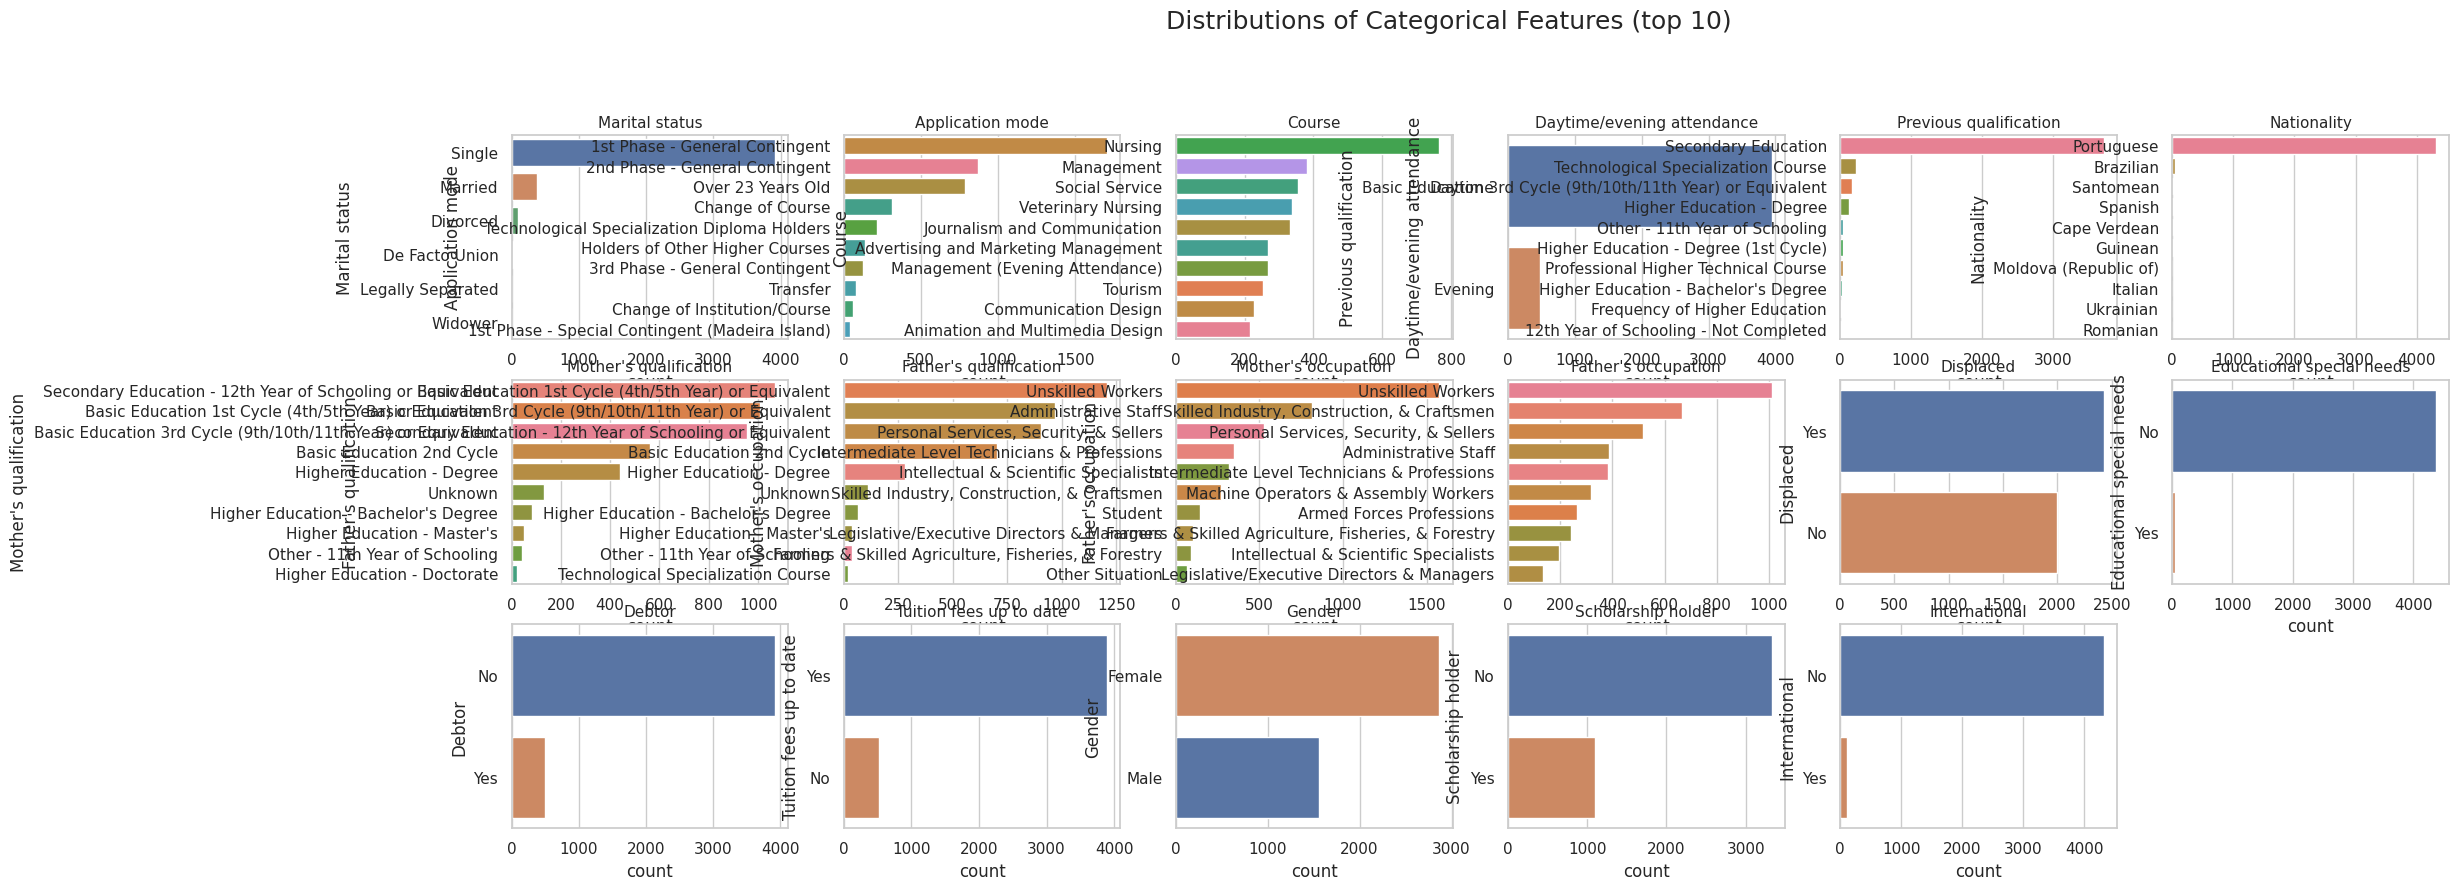

In [174]:
import math

# Re-evaluate numerical and categorical columns after all data transformations
X_num = df.select_dtypes(include=[np.number]).columns.drop('Target', errors='ignore').tolist()
X_cat = df.select_dtypes(exclude=[np.number]).columns.drop('Target', errors='ignore').tolist()

# Numerical histograms (grid)
# Dynamically calculate rows and columns for numerical plots
num_cols = 4 # Number of columns for numerical plots
num_rows = math.ceil(len(X_num) / num_cols)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 3)) # Adjusted figsize
flat = axes.flatten()
for i, col in enumerate(X_num):
    sns.histplot(df[col].dropna(), kde=True, ax=flat[i], color='steelblue')
    flat[i].set_title(col, fontsize=11)
for j in range(len(X_num), len(flat)): # Hide any leftover empty axes
    fig.delaxes(flat[j])
plt.suptitle('Distributions of Numerical Features', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# Outlier screen (boxplots)
# Use the same dynamic sizing as for histograms
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 3)) # Adjusted figsize
flat = axes.flatten()
for i, col in enumerate(X_num):
    sns.boxplot(y=df[col], ax=flat[i], color='lightgreen')
    flat[i].set_title(f'Boxplot of {col}', fontsize=11)
for j in range(len(X_num), len(flat)): # Hide any leftover empty axes
    fig.delaxes(flat[j])
plt.tight_layout()
plt.show()

# Categorical countplots (grid)
# Dynamically calculate rows and columns for categorical plots
cat_cols = 6 # Number of columns for categorical plots
cat_rows = math.ceil(len(X_cat) / cat_cols)
fig, axes = plt.subplots(cat_rows, cat_cols, figsize=(25, cat_rows * 3)) # Adjusted figsize
flat = axes.flatten()
for i, col in enumerate(X_cat):
    sns.countplot(data=df, y=col, ax=flat[i],
                  order=df[col].value_counts().head(10).index, hue=col, legend=False)
    flat[i].set_title(col, fontsize=11)
for j in range(len(X_cat), len(flat)): # Hide any leftover empty axes
    fig.delaxes(flat[j])
plt.suptitle('Distributions of Categorical Features (top 10)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### BIVARIATE ANALYSIS – Numerical Features vs Target

BIVARIATE ANALYSIS – Numerical Features vs Target


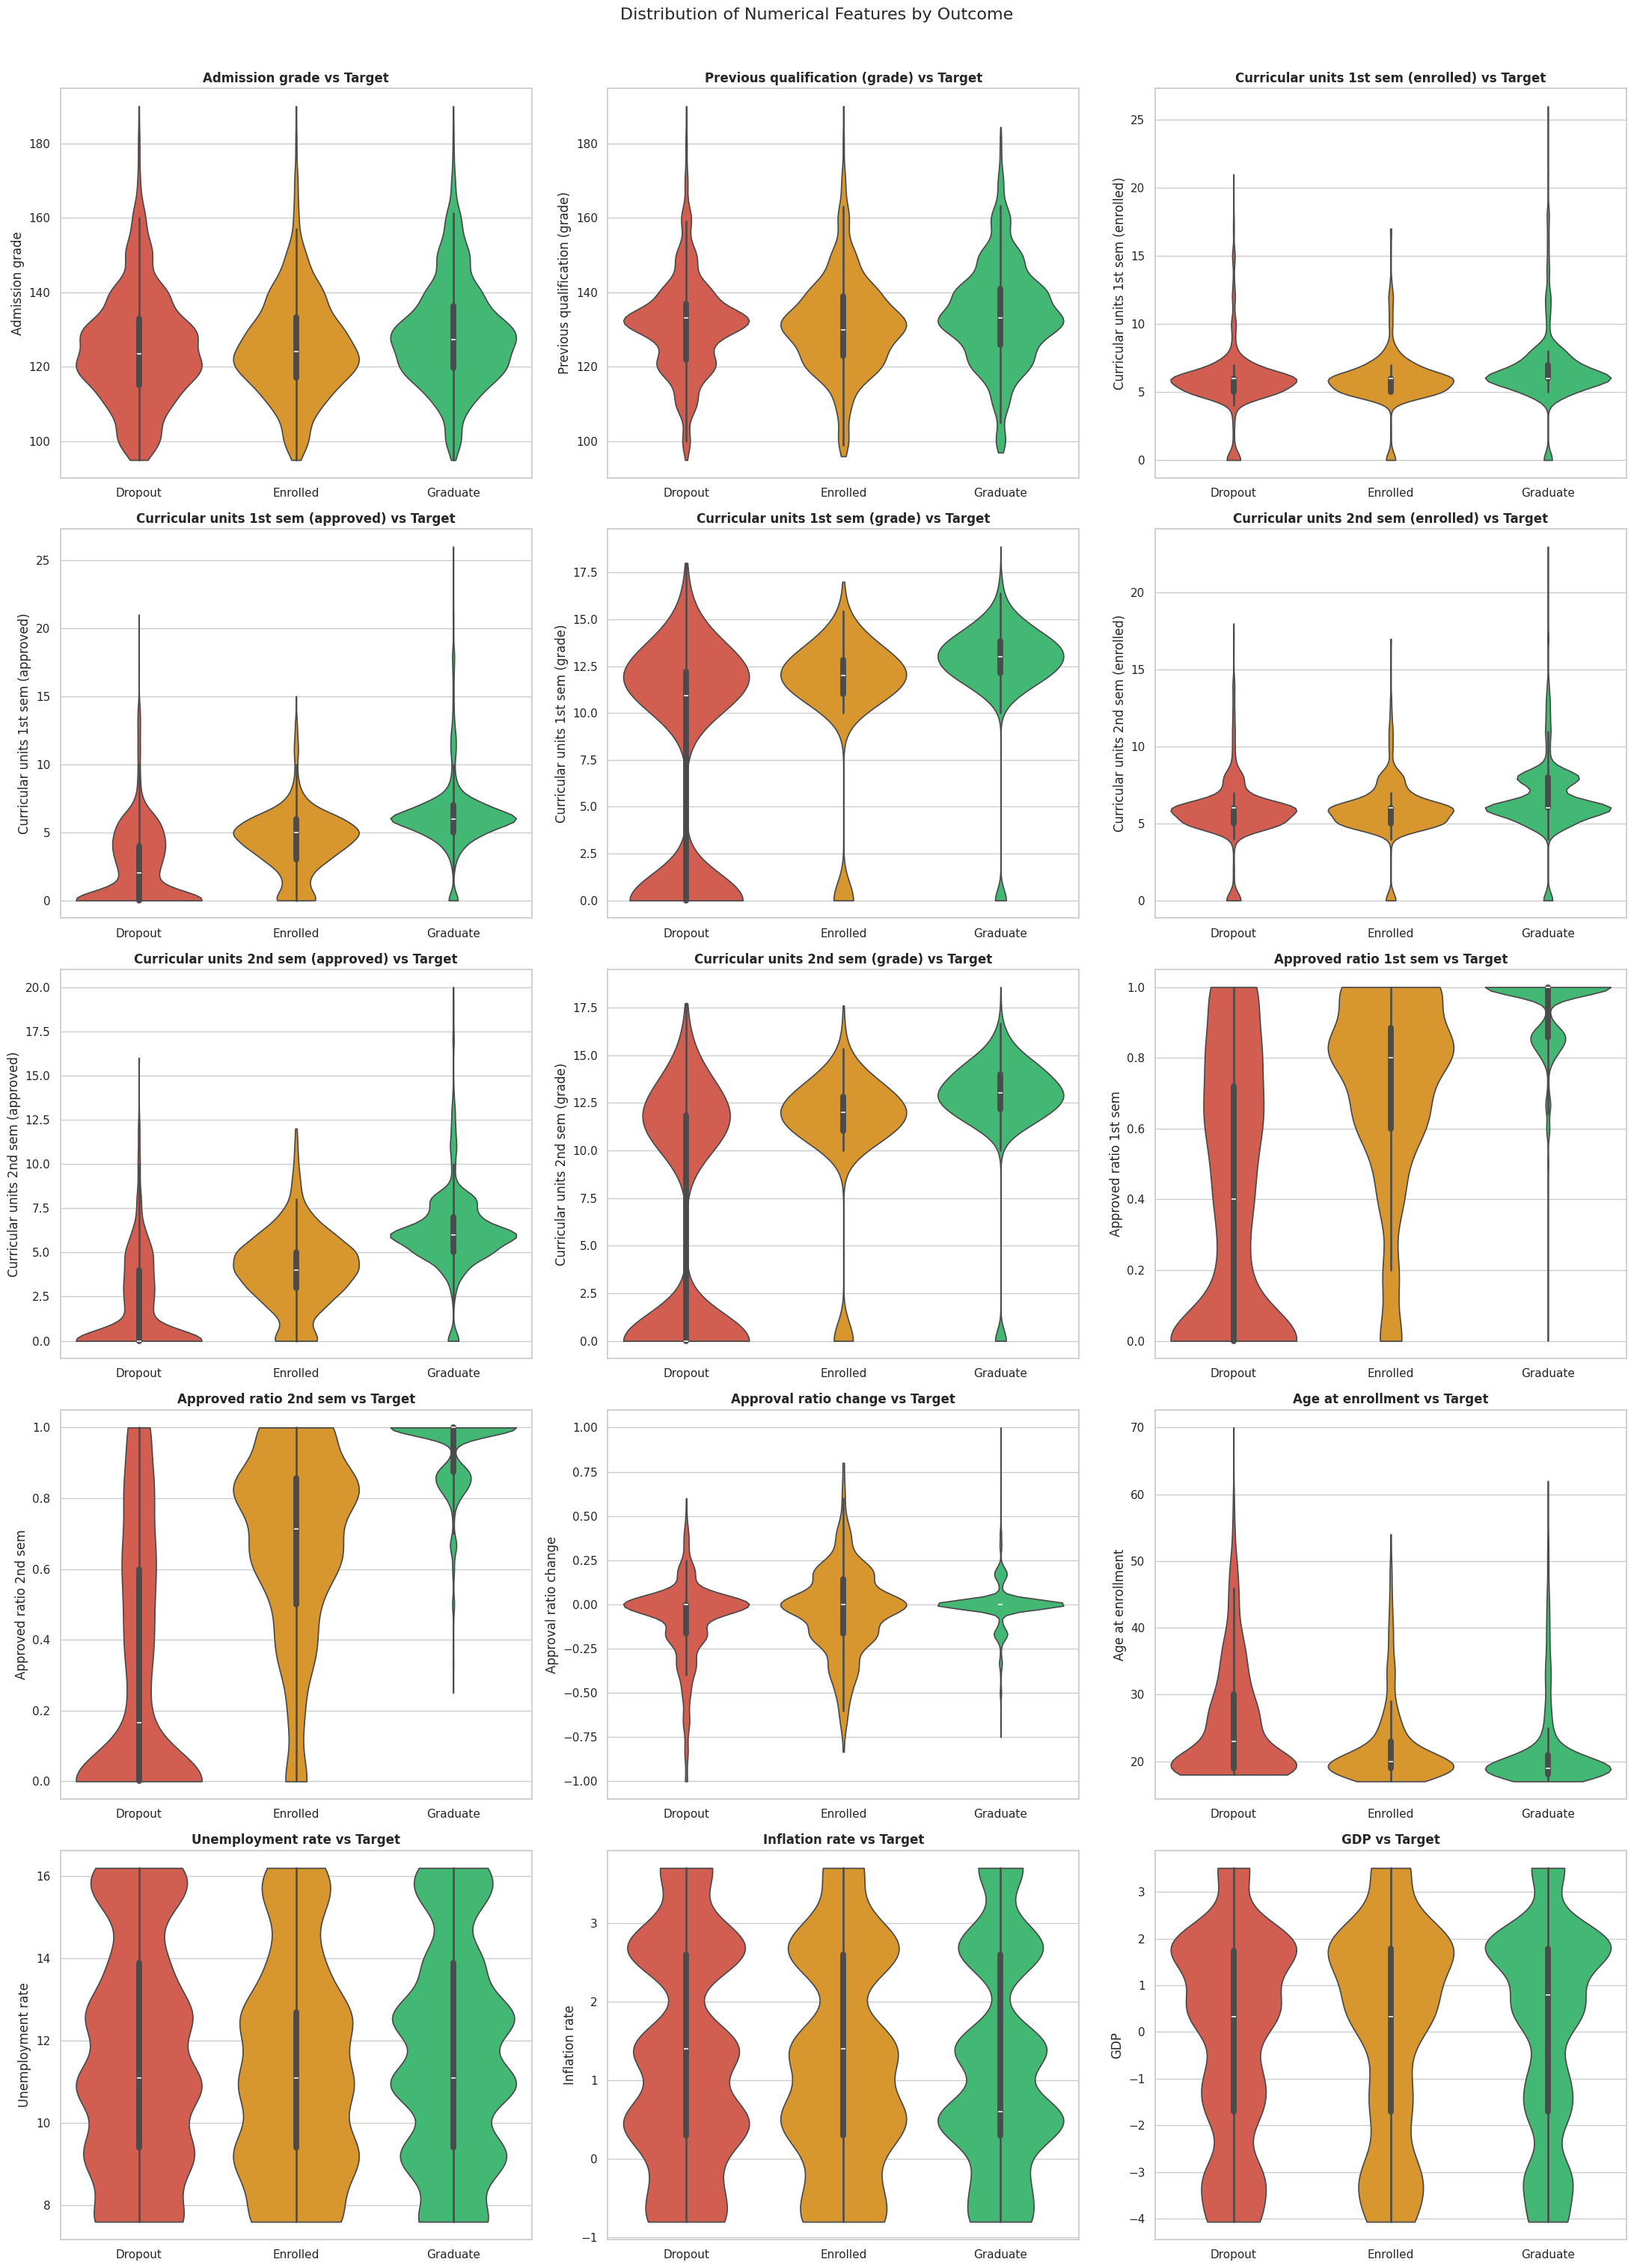

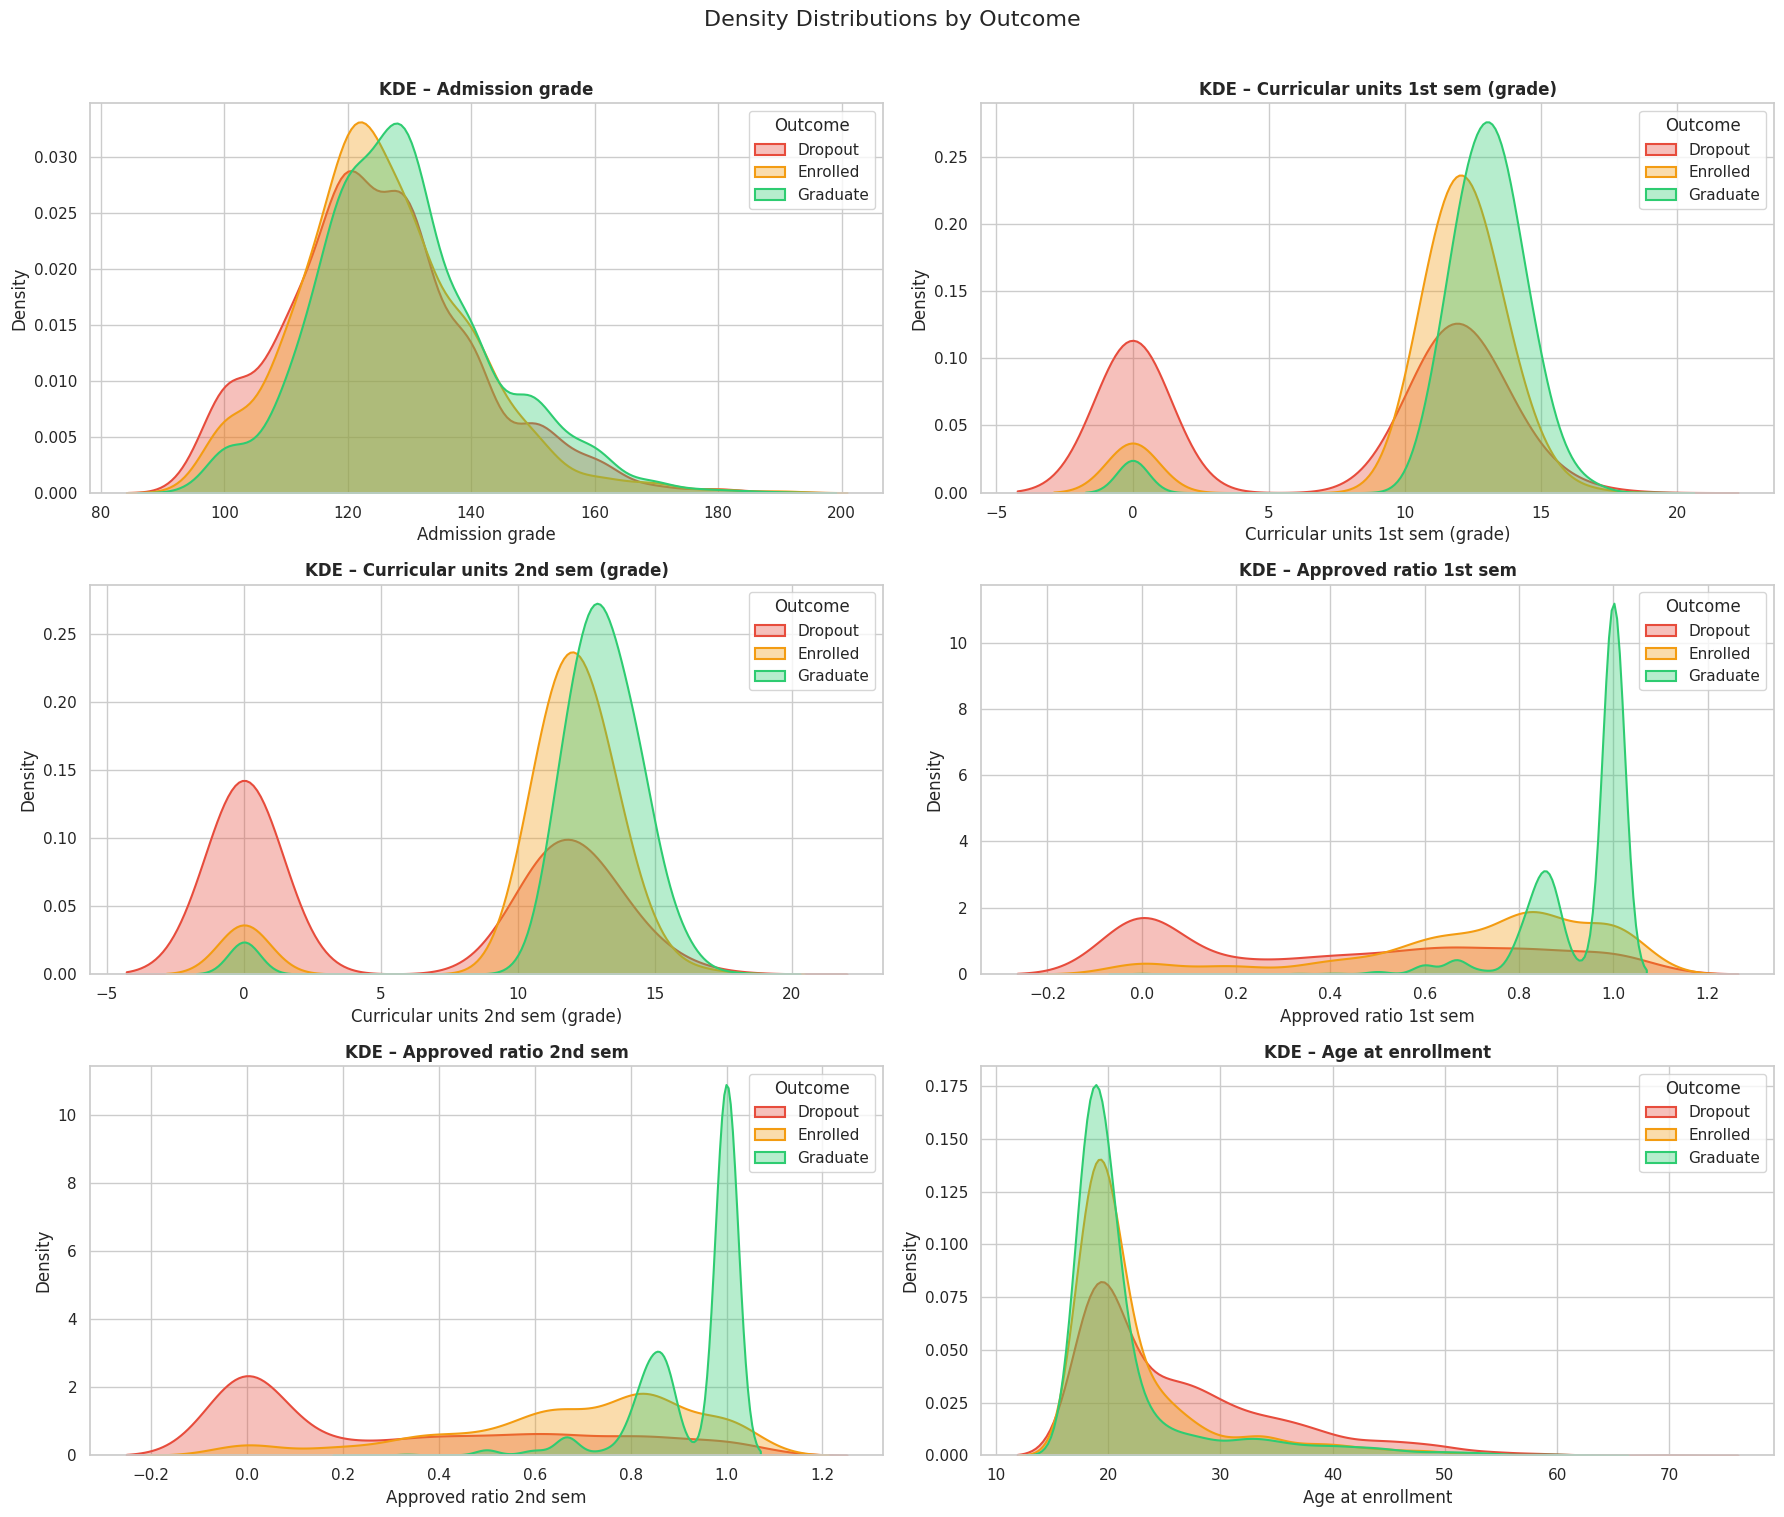

Admission grade                Previous qualification (grade)                 \
                    mean median     std                           mean median     std   
Target                                                                                  
Dropout          124.961  123.6  15.125                        131.114  133.1  12.873   
Enrolled         125.534  124.1  13.793                        131.208  130.0  12.872   
Graduate         128.794  127.4  14.071                        134.083  133.1  13.342   

         Curricular units 1st sem (enrolled)               Curricular units 1st sem (approved)  \
                                        mean median    std                                mean   
Target                                                                                           
Dropout                                5.821    6.0  2.326                               2.552   
Enrolled                               5.965    6.0  1.988                               4.319   
Graduate                               6.670    6.0  2.665                               6.232   

                       Curricular units 1st sem (grade)                 \
         median    std                             mean  median    std   
Target                                                                   
Dropout     2.0  2.858                            7.257  10.929  6.031   
Enrolled    5.0  2.289                           11.125  12.000  3.675   
Graduate    6.0  2.583                           12.644  13.000  2.699   

         Curricular units 2nd sem (enrolled)               Curricular units 2nd sem (approved)  \
                                        mean median    std                                mean   
Target                                                                                           
Dropout                                5.780    6.0  2.108                               1.940   
Enrolled                               5.938    6.0  1.831                               4.058   
Graduate                               6.628    6.0  2.297                               6.177   

                       Curricular units 2nd sem (grade)               Approved ratio 1st sem  \
         median    std                             mean median    std                   mean   
Target                                                                                         
Dropout     0.0  2.574                            5.899    0.0  6.119                  0.406   
Enrolled    4.0  2.180                           11.117   12.0  3.601                  0.714   
Graduate    6.0  2.269                           12.697   13.0  2.686                  0.935   

                       Approved ratio 2nd sem               Approval ratio change                \
         median    std                   mean median    std                  mean median    std   
Target                                                                                            
Dropout     0.4  0.372                  0.310  0.167  0.354                -0.096    0.0  0.233   
Enrolled    0.8  0.274                  0.673  0.714  0.267                -0.040    0.0  0.243   
Graduate    1.0  0.108                  0.932  1.000  0.109                -0.003    0.0  0.124   

         Age at enrollment               Unemployment rate               Inflation rate         \
                      mean median    std              mean median    std           mean median   
Target                                                                                           
Dropout             26.069   23.0  8.704            11.616   11.1  2.768          1.284    1.4   
Enrolled            22.369   20.0  6.303            11.273   11.1  2.628          1.212    1.4   
Graduate            21.784   19.0  6.693            11.639   11.1  2.601          1.198    0.6   

                   GDP                
            std   mean median    std  
Target      

In [175]:
print("=" * 60)
print("BIVARIATE ANALYSIS – Numerical Features vs Target")
print("=" * 60)

# Curate the most informative numerical columns
num_vs_target_cols = [
    "Admission grade",
    "Previous qualification (grade)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Approved ratio 1st sem",
    "Approved ratio 2nd sem",
    "Approval ratio change",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]

# Keep only columns that actually exist in the dataframe
num_vs_target_cols = [c for c in num_vs_target_cols if c in df.columns]

target_order = ["Dropout", "Enrolled", "Graduate"]
palette_target = {"Dropout": "#e74c3c", "Enrolled": "#f39c12", "Graduate": "#2ecc71"}

# --- 1a. Violin plots (distribution shape by class) ---
fig, axes = plt.subplots(5, 3, figsize=(22, 30))
axes = axes.flatten()

for i, col in enumerate(num_vs_target_cols):
    ax = axes[i]
    sns.violinplot(
        data=df, x="Target", y=col,
        order=target_order, palette=palette_target,
        inner="box", cut=0, ax=ax, hue='Target', legend=False
    )
    ax.set_title(f"{col} vs Target", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(col)

# Hide any leftover empty axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribution of Numerical Features by Outcome", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# --- 1b. Overlaid KDE plots (density curves by class) ---
kde_cols = [
    "Admission grade",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Approved ratio 1st sem",
    "Approved ratio 2nd sem",
    "Age at enrollment",
]
kde_cols = [c for c in kde_cols if c in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(kde_cols):
    ax = axes[i]
    for cls, color in palette_target.items():
        subset = df.loc[df["Target"] == cls, col].dropna()
        if len(subset) > 0:
            sns.kdeplot(subset, ax=ax, label=cls, color=color,
                        fill=True, alpha=0.35, linewidth=1.5)
    ax.set_title(f"KDE – {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(title="Outcome")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Density Distributions by Outcome", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# --- 1c. Summary table: mean / median / std per class ---
summary_num = (
    df.groupby("Target", observed=True)[num_vs_target_cols]
      .agg(["mean", "median", "std"])
      .round(3)
)
display(summary_num)

# Insights from Summary Statistics by Target

## Academic Performance
- **Admission & previous grades**: Higher for graduates (\~129–134) than dropouts (~125–131).
- **1st semester**:
  - Dropouts: ~6 enrolled, ~2.6 approved, grades ~7.3.
  - Graduates: ~6.7 enrolled, ~6.2 approved, grades ~12.6.
- **2nd semester**:
  - Dropouts: ~6 enrolled, ~2 approved.
  - Graduates: ~6.6 enrolled, ~6.2 approved.
- **Approval ratios**:
  - Dropouts: ~0.41 (1st sem), ~0.31 (2nd sem).
  - Graduates: ~0.94 (1st sem), ~0.93 (2nd sem).
  - Change: Dropouts decline further, graduates remain stable.

## Demographics
- **Age at enrollment**:
  - Dropouts: Older (mean ~26).
  - Graduates: Younger (mean ~22).

## External Context
- **Unemployment rate**: Similar (~11.3–11.6).
- **Inflation rate**: Slightly lower for graduates (~1.2 vs ~1.4).
- **GDP growth**:
  - Dropouts: Mean ≈ –0.15 (negative years).
  - Graduates: Mean ≈ +0.08 (positive years).
  - → Students entering during recessions faced higher dropout risk.

## Insights
- **Strong predictors of success**: Admission grade, previous qualification grade, semester approvals, and approval ratios.
- **Dropout risk factors**: Lower grades, fewer approvals, declining approval ratios, older age at enrollment, and enrollment during recession years.
- **External features**: GDP and inflation show meaningful differences, Unemployment differences are minor. Academic performance remains the dominant predictor, but external economic context adds an important layer: students entering during stable or growing economies had better chances of graduating.


### BIVARIATE ANALYSIS – Categorical Features vs Target

BIVARIATE ANALYSIS – Categorical Features vs Target


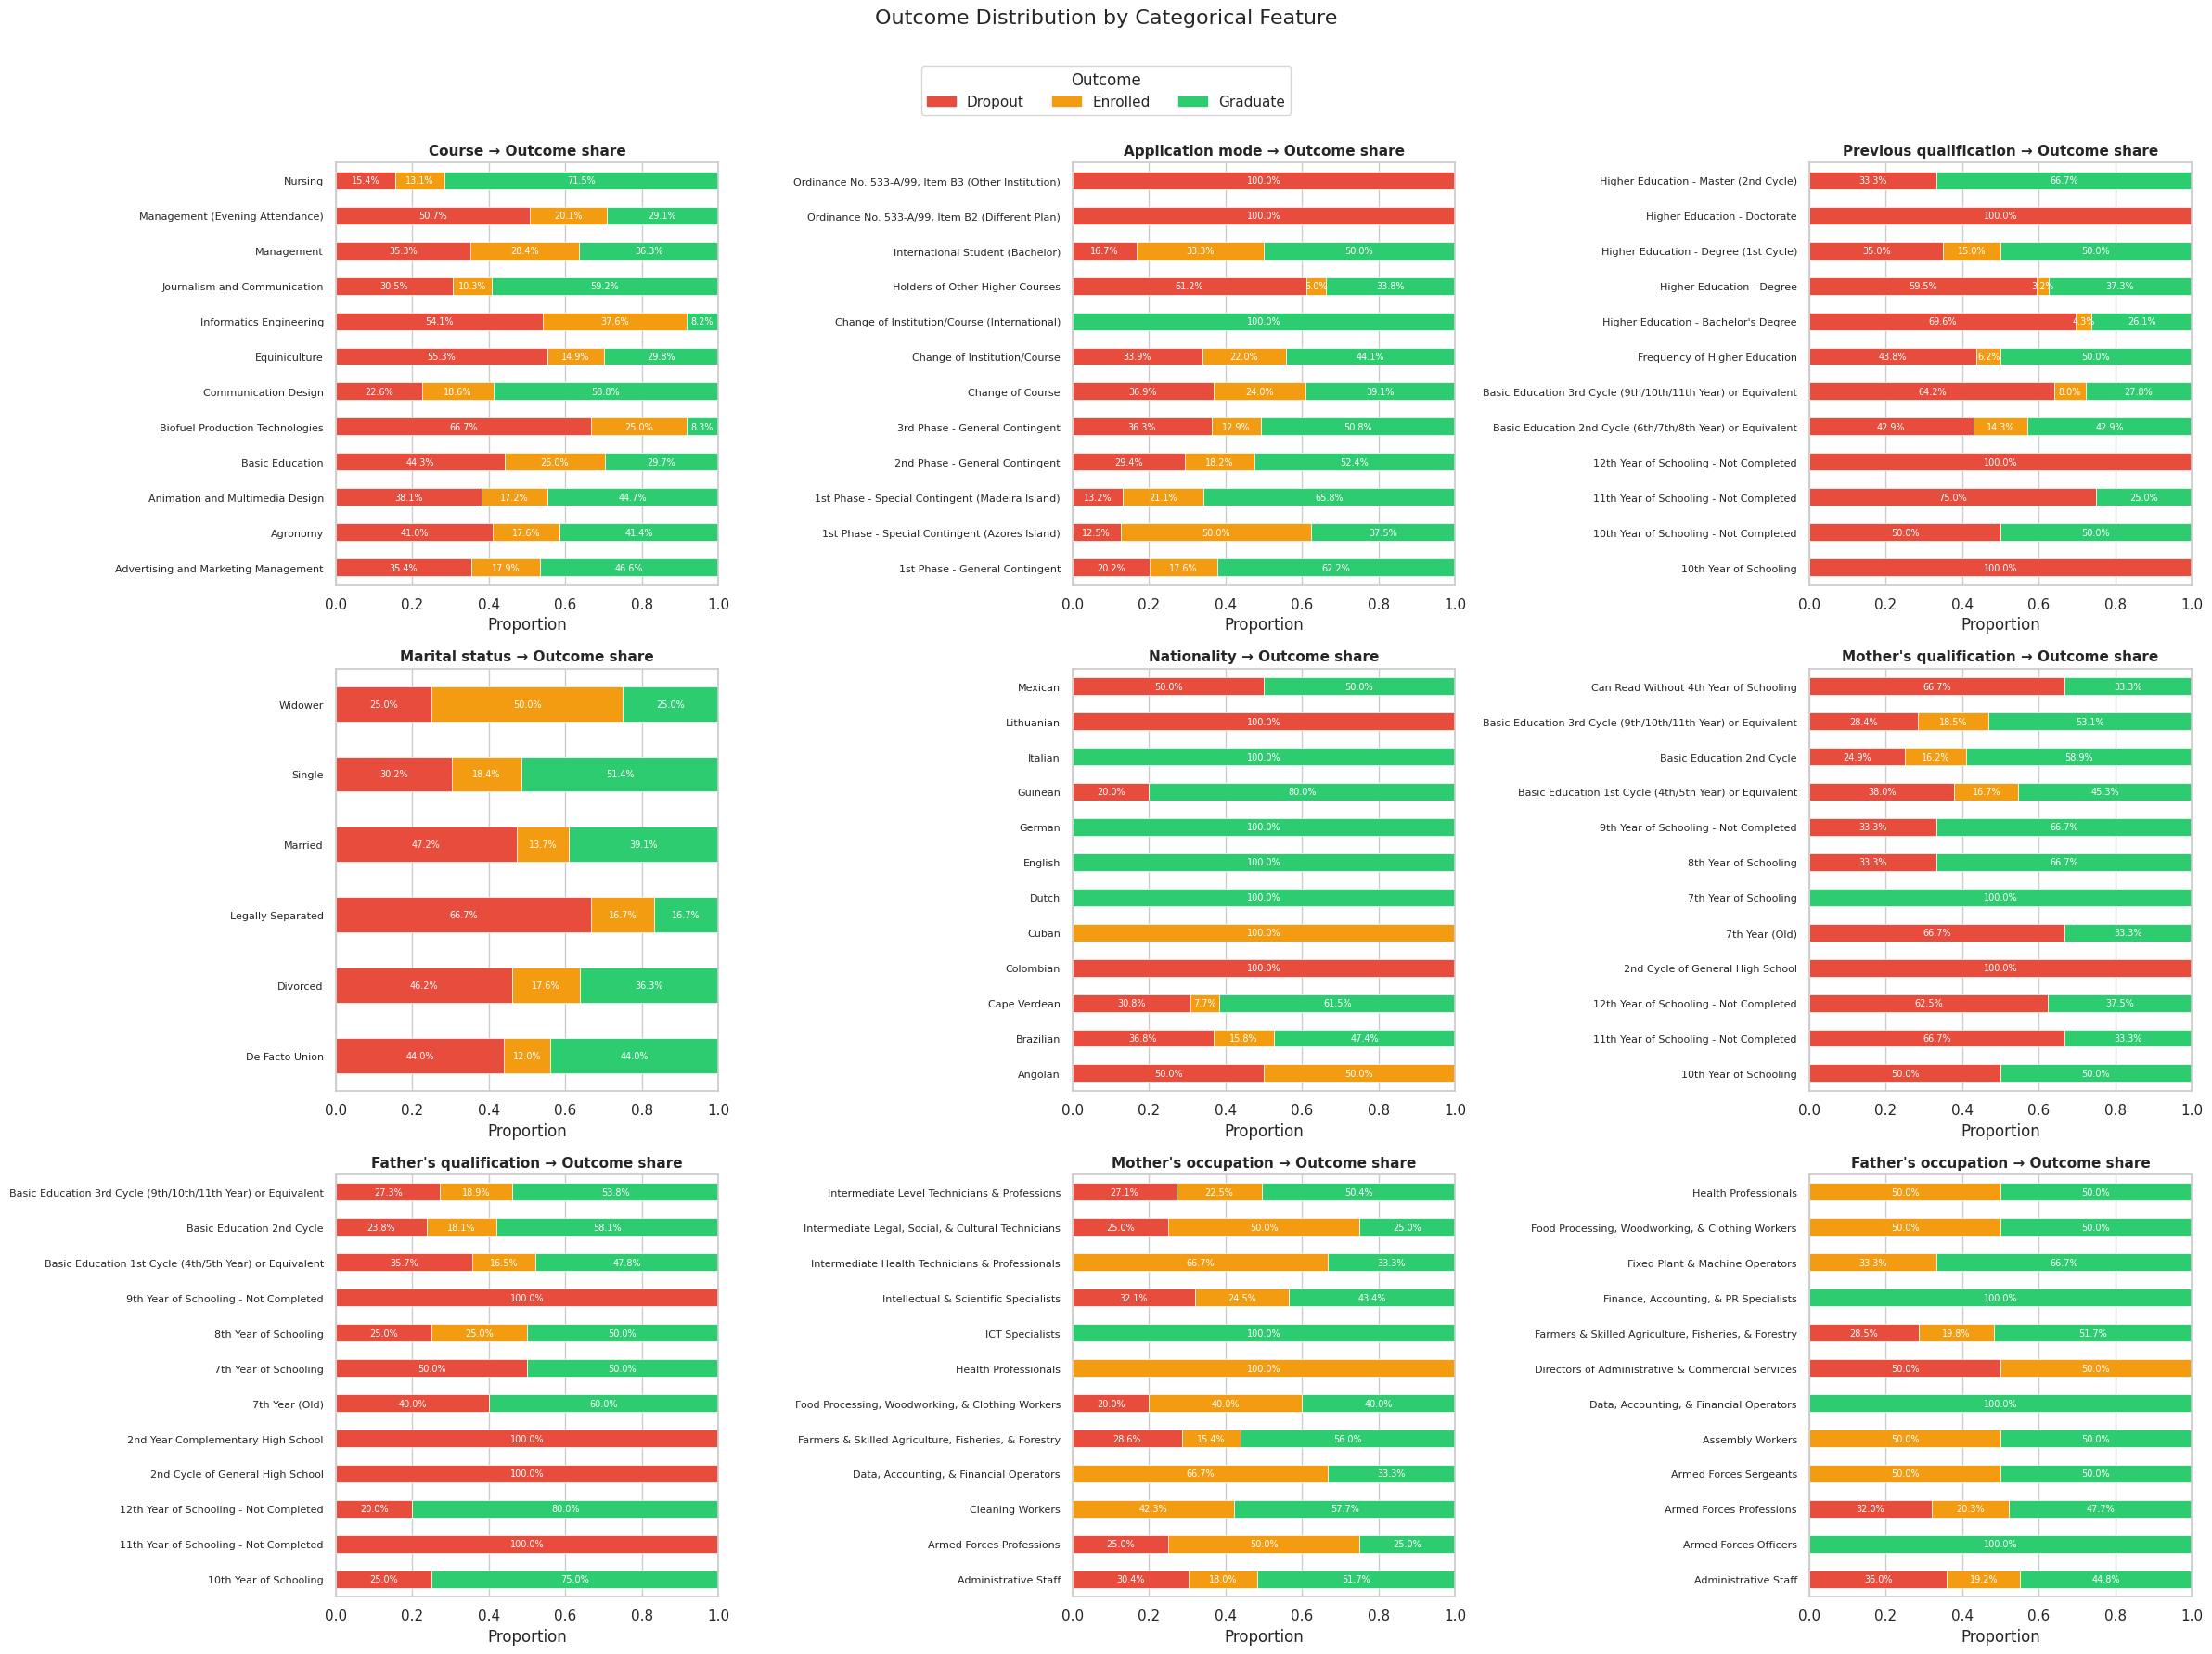

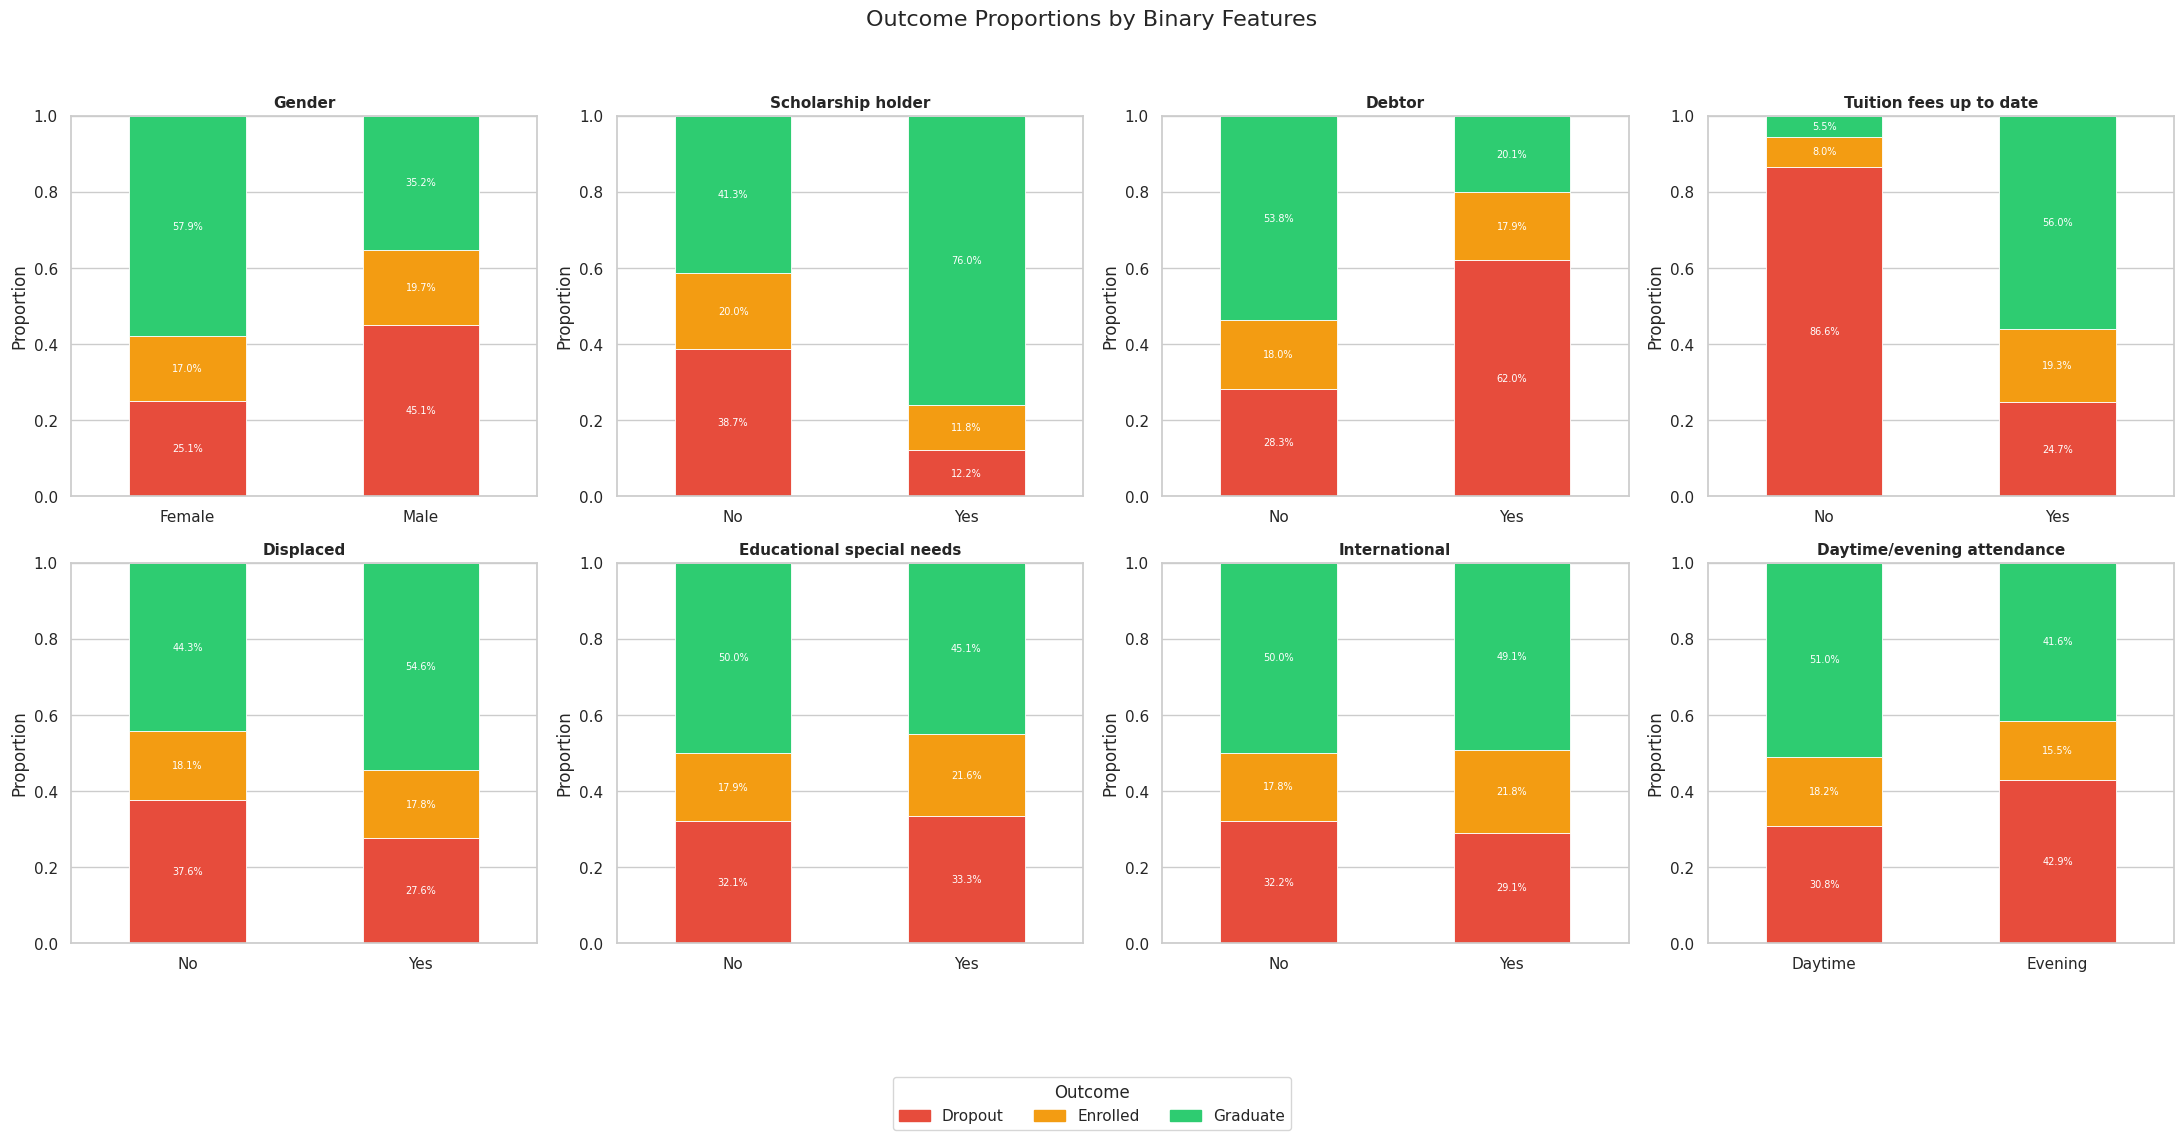


# --- Outcome rate table for Course


Target,Dropout,Enrolled,Graduate,Dropout_rate,Enrolled_rate,Graduate_rate
Course,,,,,,
Biofuel Production Technologies,8,3,1,0.667,0.250,0.083
Equiniculture,78,21,42,0.553,0.149,0.298
Informatics Engineering,92,64,14,0.541,0.376,0.082
Management (Evening Attendance),136,54,78,0.507,0.201,0.291
Basic Education,85,50,57,0.443,0.260,0.297
Agronomy,86,37,87,0.410,0.176,0.414
Oral Hygiene,33,17,36,0.384,0.198,0.419
Tourism,96,41,115,0.381,0.163,0.456
Animation and Multimedia Design,82,37,96,0.381,0.172,0.447



# --- Outcome rate table for Application mode


Target,Dropout,Enrolled,Graduate,Dropout_rate,Enrolled_rate,Graduate_rate
Application mode,,,,,,
"Ordinance No. 533-A/99, Item B2 (Different Plan)",1,0,0,1.000,0.000,0.000
"Ordinance No. 533-A/99, Item B3 (Other Institution)",1,0,0,1.000,0.000,0.000
Ordinance No. 612/93,2,0,1,0.667,0.000,0.333
Holders of Other Higher Courses,85,7,47,0.612,0.050,0.338
Over 23 Years Old,435,121,229,0.554,0.154,0.292
Transfer,34,11,32,0.442,0.143,0.416
Change of Course,115,75,122,0.369,0.240,0.391
3rd Phase - General Contingent,45,16,63,0.363,0.129,0.508
Change of Institution/Course,20,13,26,0.339,0.220,0.441



# --- Outcome rate table for Previous qualification


...

Target,Dropout,Enrolled,Graduate,Dropout_rate,Enrolled_rate,Graduate_rate
Father's qualification,,,,,,
11th Year of Schooling - Not Completed,2,0,0,1.000,0.000,0.000
2nd Cycle of General High School,1,0,0,1.000,0.000,0.000
Technical-Professional Course,4,0,0,1.000,0.000,0.000
2nd Year Complementary High School,1,0,0,1.000,0.000,0.000
9th Year of Schooling - Not Completed,3,0,0,1.000,0.000,0.000
General Commerce Course,1,0,0,1.000,0.000,0.000
Complementary High School - Not Concluded,1,0,0,1.000,0.000,0.000
Complementary High School Course,1,0,0,1.000,0.000,0.000
Frequency of Higher Education,2,0,0,1.000,0.000,0.000



# --- Outcome rate table for Mother's occupation


Target,Dropout,Enrolled,Graduate,Dropout_rate,Enrolled_rate,Graduate_rate
Mother's occupation,,,,,,
Not Reported (Blank),13,2,2,0.765,0.118,0.118
Other Situation,51,0,19,0.729,0.000,0.271
Student,99,1,44,0.688,0.007,0.306
Machine Operators & Assembly Workers,15,7,14,0.417,0.194,0.389
Legislative/Executive Directors & Managers,39,15,48,0.382,0.147,0.471
Intellectual & Scientific Specialists,102,78,138,0.321,0.245,0.434
Unskilled Workers,490,264,823,0.311,0.167,0.522
Administrative Staff,248,147,422,0.304,0.180,0.517
"Skilled Industry, Construction, & Craftsmen",80,48,144,0.294,0.176,0.529



# --- Outcome rate table for Father's occupation


Target,Dropout,Enrolled,Graduate,Dropout_rate,Enrolled_rate,Graduate_rate
Father's occupation,,,,,,
Other Situation,46,0,19,0.708,0.000,0.292
Not Reported (Blank),13,2,4,0.684,0.105,0.211
Student,82,3,43,0.641,0.023,0.336
Meal Preparation Assistants,1,0,1,0.500,0.000,0.500
Directors of Administrative & Commercial Services,1,1,0,0.500,0.500,0.000
Administrative Staff,139,74,173,0.360,0.192,0.448
Legislative/Executive Directors & Managers,48,23,63,0.358,0.172,0.470
Intellectual & Scientific Specialists,70,50,77,0.355,0.254,0.391
Sellers,1,2,0,0.333,0.667,0.000


In [176]:
print("=" * 60)
print("BIVARIATE ANALYSIS – Categorical Features vs Target")
print("=" * 60)

cat_vs_target_cols = [
    "Course",
    "Application mode",
    "Previous qualification",
    "Marital status",
    "Nationality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]
cat_vs_target_cols = [c for c in cat_vs_target_cols if c in df.columns]

legend_handles = [plt.Rectangle((0,0),1,1, color=palette_target[cls]) for cls in target_order]
legend_labels = target_order

# --- 2a. Stacked bar charts: outcome distribution per category ---
n_cats = len(cat_vs_target_cols)
n_cols_grid = 3
n_rows_grid = int(np.ceil(n_cats / n_cols_grid))

fig1, axes1 = plt.subplots(n_rows_grid, n_cols_grid,
                         figsize=(24, 6 * n_rows_grid))
axes1 = axes1.flatten()

for i, col in enumerate(cat_vs_target_cols):
    ax = axes1[i]
    # Calculate proportions
    ct = pd.crosstab(df[col], df["Target"], normalize="index")
    ct = ct.reindex(columns=target_order).dropna(how="all")

    # Limit to top-12 categories if the feature has many levels
    if ct.shape[0] > 12:
        if 'UNMAPPED - CHECK' in ct.index:
            ct_temp = ct.drop('UNMAPPED - CHECK')
            top_cats = ct_temp.index[:11].tolist() + ['UNMAPPED - CHECK']
        else:
            top_cats = ct.index[:12]
        ct = ct.loc[top_cats]

    ct.plot(kind="barh", stacked=True, ax=ax,
            color=[palette_target[c] for c in target_order],
            edgecolor="white", linewidth=0.5, legend=False)

    ax.set_title(f"{col} \u2192 Outcome share", fontsize=11, fontweight="bold")
    ax.set_xlabel("Proportion")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)

    # Add proportion percentages on the bars
    for container in ax.containers:
        for patch in container.patches:
            width = patch.get_width()
            if width > 0.03:
                x_text = patch.get_x() + width / 2
                y_text = patch.get_y() + patch.get_height() / 2
                ax.text(x_text, y_text, f'{width:.1%}', ha='center', va='center', color='white', fontsize=7)

    # Reset x-axis limit to default
    ax.set_xlim(0, 1.0)

for j in range(i + 1, len(axes1)):
    axes1[j].axis("off")

plt.suptitle("Outcome Distribution by Categorical Feature",
             fontsize=16, y=1.02)
fig1.legend(handles=legend_handles, labels=legend_labels, title="Outcome",
           bbox_to_anchor=(0.5, 0.99), loc='upper center', ncol=len(target_order))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# --- 2b. Count-based grouped bars for the top binary features ---
binary_cols = [
    "Gender", "Scholarship holder", "Debtor",
    "Tuition fees up to date", "Displaced",
    "Educational special needs", "International",
    "Daytime/evening attendance",
]
binary_cols = [c for c in binary_cols if c in df.columns]

fig2, axes2 = plt.subplots(2, 4, figsize=(22, 10))
axes2 = axes2.flatten()

for i, col in enumerate(binary_cols):
    ax = axes2[i]
    ct_normalized = pd.crosstab(df[col], df["Target"], normalize='index').reindex(columns=target_order).fillna(0)
    ct_normalized.plot(kind="bar", stacked=True, ax=ax,
            color=[palette_target[c] for c in target_order],
            edgecolor="white", linewidth=0.6, legend=False)
    ax.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=0)

    # Add proportion percentages on the bars
    for container in ax.containers:
        for patch in container.patches:
            height = patch.get_height()
            if height > 0.03:
                x_text = patch.get_x() + patch.get_width() / 2
                y_text = patch.get_y() + height / 2
                ax.text(x_text, y_text, f'{height:.1%}', ha='center', va='center', color='white', fontsize=7)

    # Reset y-axis limit to default
    ax.set_ylim(0, 1.0)

for j in range(i + 1, len(axes2)):
    axes2[j].axis("off")

plt.suptitle("Outcome Proportions by Binary Features", fontsize=16, y=1.01)
fig2.legend(handles=legend_handles, labels=legend_labels, title="Outcome",
           bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=len(target_order))
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


# --- 2c.1. Outcome rate tables for large & mid-sized categorical features ---

categorical_features = [
    "Course",
    "Application mode",
    "Previous qualification",
    "Marital status",
    "Nationality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

for feature in categorical_features:
    print(f"\n# --- Outcome rate table for {feature}")

    # Counts
    count_table = pd.crosstab(df[feature], df["Target"])
    count_table.columns = count_table.columns.astype(str)

    # Rates
    rate_table = pd.crosstab(
        df[feature], df["Target"], normalize="index"
    ).reindex(columns=target_order).round(3)
    rate_table.columns = rate_table.columns.astype(str)

    # Combine
    combined_table = count_table.join(rate_table, rsuffix="_rate")

    # Reorder columns for clarity
    combined_table = combined_table[
        ["Dropout", "Enrolled", "Graduate", "Dropout_rate", "Enrolled_rate", "Graduate_rate"]
    ]

    combined_table = combined_table.sort_values("Dropout_rate", ascending=False)

    display(combined_table)

# Refined Insights from Categorical Features vs Target

## Course
- **Strong dropout**:
  - Equiniculture → 55.3% (n=78 dropouts).
  - Informatics Engineering → 54.1% (n=92 dropouts).
  - Management (Evening Attendance) → 50.7% (n=136 dropouts).
- **Strong graduation**:
  - Nursing → 71.5%(n=548 graduates)
  - Social Service → 69.9%(n=248 graduates)
  - Journalism and Communication → 59.2%(n=196 graduates)
  - Communication Design → 58.8%(n=133 graduates)
  - Social Service (Evening Attendance) → 57.2%(n=123 graduates)
  - Veterinary Nursing→ 51%(n=172 graduates)
- **Insight**: Outcomes vary sharply by program - **health and social service fields show the strongest persistence**, while **technical and evening management tracks face elevated dropout risk**.

---

## Application Mode
- **Strong dropout**:
  - Holders of Other Higher Courses → 61% (n=85 dropouts).
  - Over 23 Year Old → 55% (n=435 dropouts).
- **Strong graduation**:
  - 1st Phase - General Contingent → 62.2%(n=1063 graduates)
  - 2nd Phase - General Contingent → 52.4%(n=457 graduates)
  - 3rd Phase - General Contingent → 50.8%(n=63 graduates)
- **Insight**: Dropout risk is concentrated among **older applicants and those entering with prior higher courses**, while **mainstream general contingent admissions consistently show strong graduation outcomes**.

---

## Previous Qualification
- **Strong dropout**:  
  - Basic Education 3rd Cycle (9th/10th/11th Year or Equivalent) → 64.2% (n=104 dropouts)  
  - Higher Education – Degree → 59.5% (n=75 dropouts)  
- **Strong graduation**:  
  - Secondary Education → 52.2% (n=1,941 graduates)  
- **Insight**: Students entering with **lower‑cycle education or prior higher degrees face elevated dropout risk**, while those with **secondary education backgrounds show the strongest graduation outcomes**.

---

## Marital Status
- **Legally Separated** → Dropout 66.7% (n=4), Graduation 16.7% (n=1)  
- **Married** → Dropout 47.2% (n=179), Graduation 39.1% (n=148)  
- **Divorced** → Dropout 46.2% (n=42), Graduation 36.3% (n=33)  
- **De Facto Union** → Dropout 44.0% (n=11), Graduation 44.0% (n=11)  
- **Single** → Dropout 30.2% (n=1,184), Graduation 51.4% (n=2,015)  
- **Widower** → Dropout 25.0% (n=1), Graduation 25.0% (n=1)  
- **Insight**: **Single students show the strongest persistence and graduation**, while **married, divorced, and legally separated groups face higher dropout risk**, reflecting the impact of family circumstances on academic outcomes.

---

## Gender
- **Male students** → Dropout 45.1%, Graduation 35.2%.  
- **Female students** → Dropout 25.1%, Graduation 57.9%.  
- **Insight**: Gender differences are clear - **female students persist and graduate at much higher rates**, while **male students face elevated dropout risk**.

---

## Attendance (Daytime vs Evening)
- **Evening programs** → Dropout 42.9%, Graduation 41.6%.  
- **Daytime programs** → Dropout 30.8%, Graduation 51.0%.  
- **Insight**: Evening cohorts show **notably higher dropout** and lower graduation compared to daytime, reflecting the added challenges of balancing work and family responsibilities.

---

## Nationality
- **Extreme dropout**: Colombian (100%), Lithuanian (100%).  
- **High dropout**: Moldova (66.7%), Russian (50.0%), Angolan (50.0%).  
- **Strong graduation**: Guinean (80.0%), Ukrainian (66.7%), Cape Verdean (61.5%), Santomean (57.1%).  
- **Balanced graduation (~50%)**: Portuguese, Mexican, Mozambican, Romanian.  
- **Perfect graduation (likely very small n)**: Dutch, English, German, Italian.  
- **Mixed outcomes**: Brazilian (47.4% graduation), Spanish (30.8% graduation, 30.8% dropout).  
- **Insight**: Extreme outcomes in smaller national groups reflect **tiny sample sizes** and should be interpreted cautiously. Since the dataset is **predominantly Portuguese**, the most reliable signal is the balanced 50/50 graduation rate among Portuguese students, while other nationalities provide only limited, anecdotal patterns.

---

## Mother’s Qualifications
- **Unknown** → Dropout 73.8% (n = 96 dropouts), Graduation 23.8% (n =31 graduates)  
- **Basic Education 1st Cycle (4th/5th Year) or Equivalent** → Dropout 38% (n = 383 dropouts), Graduation 45.3% (n = 457 graduates)  
- **Higher Education - Degree** → Dropout 31.7% (n = 139 dropouts), Graduation 45.2% (n = 198 graduates)  
- **Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent** → Dropout 28.4% (n = 271 dropouts), Graduation 53.1% (n = 506 graduates)  
- **Secondary Education - 12th Year of Schooling or Equivalent** → Dropout 28.1% (n = 300 dropouts), Graduation 52.9% (n = 565 graduates)  
- **Basic Education 2nd Cycle** → Dropout 24.9% (n = 140 dropouts), Graduation 58.9% (n = 331 graduates)  
-**Higher Education - Bachelor's Degree** → Dropout 24.1% (n = 20 dropouts), Graduation 48.2% (n = 40 graduates)  
- **Insight**:  
  - **Highest dropout**: Students with mothers of *Unknown qualification* (73.8%).
  - **Strong graduation**: *Basic Education 2nd Cycle* (58.9%), *Basic Education 3rd Cycle* (53.1%), and *Secondary Education* (52.9%) stand out as protective factors.  
  - **Note**: Smaller categories (<50) are excluded due to unreliable sample sizes.

---

## Father's Qualifications
- **Unknown** → Dropout 72.3% (n = 81 dropouts), Graduation 25% (n = 28 graduates)  
- **Basic Education 1st Cycle (4th/5th Year) or Equivalent** → Dropout 35.7% (n = 432 dropouts), Graduation 47.8% (n = 578 graduates)  
- **Higher Education - Bachelor's Degree** → Dropout 32.4% (n = 22 dropouts), Graduation 30.9% (n = 21 graduates)  
- **Higher Education - Degree** → Dropout 31.9% (n = 90 dropouts), Graduation 46.1% (n = 130 graduates)  
- **Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent** → Dropout 27.3% (n = 264 dropouts), Graduation 53.8% (n = 521 graduates)  
- **Secondary Education - 12th Year of Schooling or Equivalent** → Dropout 31.1% (n = 281 dropouts), Graduation 49.9% (n = 451 graduates)  
- **Basic Education 2nd Cycle** → Dropout 23.8% (n = 167 dropouts), Graduation 58.1% (n = 408 graduates)  
- **Insight**:  
  - **Highest dropout**: Students with fathers of *Unknown qualification* (72.3%).    - **Strong graduation**: *Basic Education 2nd Cycle* (58.1%), *Basic Education 3rd Cycle* (53.8%), and *Secondary Education* (49.9%) stand out as protective factors.  
  - **Note**: Smaller categories (<50) are excluded due to unreliable sample sizes.

---

## Mother's Occupations
- **Other Situation** → Dropout 72.9% (n = 51 dropouts), Graduation 27.1% (n = 19 graduates)  
- **Student** → Dropout 68.8% (n = 99 dropouts), Graduation 30.6% (n = 44 graduates)  
- **Legislative/Executive Directors & Managers** → Dropout 38.2% (n = 39 dropouts), Graduation 47.1% (n = 48 graduates)  
- **Intellectual & Scientific Specialists** → Dropout 32.1% (n = 102 dropouts), Graduation 43.4% (n = 138 graduates)  
- **Unskilled Workerst** → Dropout 31.1% (n = 490 dropouts), Graduation 52.2% (n = 823 graduates)  
- **Administrative Staff** → Dropout 30.4% (n = 248 dropouts), Graduation 51.7% (n = 422 graduates)  
- **Skilled Industry, Construction, & Craftsmen** → Dropout 29.4% (n = 80 dropouts), Graduation 52.9% (n = 144 graduates)  
- **Personal Services, Security, & Sellers** → Dropout 29.4% (n = 156 dropouts), Graduation 52.8% (n = 280 graduates)  
- **Farmers & Skilled Agriculture, Fisheries, & Forestry** → Dropout 28.6% (n = 26 dropouts), Graduation 56% (n = 51 graduates)  
- **Intermediate Level Technicians & Professions** → Dropout 27.1% (n = 95 dropouts), Graduation 50.4% (n = 177 graduates)  
- **Insight**:  
  - **Highest dropout**: Students whose fathers are in *Other Situation* (72.9%) or *Students* (68.8%).  
  - **Strong graduation**: Occupations in *Unskilled work*, *Administrative staff*, *Skilled industry*, *Personal services*, and *Agriculture* all show graduation rates above 50%, with *Farmers & Skilled Agriculture* reaching 56%.  
  - **Overall pattern**: Traditional and labor‑based occupations correlate with **lower dropout and stronger graduation**, while uncertain or unstable statuses (Other, Student) carry the highest risk.

---

## Father's Occupation
- **Other Situation** → Dropout 70.8% (n = 46 dropouts), Graduation 29.2% (n = 19 graduates)  
- **Student** → Dropout 64.1% (n = 82 dropouts), Graduation 33.6% (n = 43 graduates)  
- **Legislative/Executive Directors & Managers** → Dropout 35.8% (n = 48 dropouts), Graduation 47% (n = 63 graduates)  
- **Intellectual & Scientific Specialists** → Dropout 35.5% (n = 70 dropouts), Graduation 39.1% (n = 77 graduates)  
- **Unskilled Workerst** → Dropout 32% (n = 323 dropouts), Graduation 51.9% (n = 524 graduates)  
- **Administrative Staff** → Dropout 36% (n = 139 dropouts), Graduation 44.8% (n = 173 graduates)  
- **Skilled Industry, Construction, & Craftsmen** → Dropout 27.6% (n = 184 dropouts), Graduation 55.7% (n = 371 graduates)  
- **Personal Services, Security, & Sellers** → Dropout 28.7% (n = 148 dropouts), Graduation 50.6% (n = 261 graduates)  
- **Farmers & Skilled Agriculture, Fisheries, & Forestry** → Dropout 28.5% (n = 69 dropouts), Graduation 51.7% (n = 125 graduates)  
- **Intermediate Level Technicians & Professions** → Dropout 29.7% (n = 114 dropouts), Graduation 53.9% (n = 207 graduates)  
- **Armed Forces Professions** → Dropout 32% (n = 85 dropouts), Graduation 47.7% (n = 127 graduates)  
- **Machine Operators & Assembly Workers** → Dropout 29.6% (n = 94 dropouts), Graduation 53.1% (n = 169 graduates)  
- **Insight**:  
  - **Highest dropout**: Fathers in *Other Situation* (70.8%) or *Students* (64.1%) - clear instability signals.   
  - **Strong graduation**: Practical and labor‑based occupations (*Skilled industry*, *Technicians*, *Machine operators*, *Agriculture*, *Personal services*) all show graduation rates above 50%.  
  - **Overall pattern**: Stable, hands‑on professions correlate with **lower dropout and stronger graduation**, while uncertain or transitional statuses (Other, Student) carry the highest risk.

---

## Scholarship Holder
- Scholarship holders → Dropout 1.22%, Graduation 76%.
- Non-scholarship → Dropout 38.7%, Graduation 41.3%.
- **Insight**: Scholarships act as a **powerful protective factor** - recipients show very low dropout and the highest graduation rates compared to non‑scholarship students.

---

## Debtor Status
- Debtors → Dropout 62%, Graduation 20.1%.
- Non-debtors → Dropout 28.3%, Graduation 53.8%.
- **Insight**: Debt is a **major dropout risk factor** - students with outstanding debts leave at far higher rates, while non‑debtors show much stronger graduation outcomes.
## Tuition Fees Up to Date
- Fees up to date → Dropout 24.7%, Graduation 56%.
- Fees not up to date → Dropout 86.6%, Graduation 5.5%.
- **Insight**: Fee payment status is the **strongest single predictor** - students not up to date almost universally drop out, while those current on fees show far higher graduation rates.

---

## Displacement
- Displaced students → Dropout 27.6%, Graduation 54.6%.
- Non-displaced → Dropout 37.6%, Graduation 44.3%.
- **Insight**: Displaced students actually show **better graduation outcomes and lower dropout** compared to non‑displaced peers, suggesting relocation does not hinder persistence and may even correlate with stronger commitment.

---

## Educational Special Needs
- Special needs → Dropout 33.3%, Graduation 45.1%.
- No special needs → Dropout 32.1%, Graduation 50%.
- **Insight**: Outcomes are **broadly similar** - students with special needs show only slightly higher dropout and lower graduation, indicating this factor is not a major differentiator of persistence.

---

## International Status
- International → Dropout 29.1%, Graduation 49.1%.
- Non-international → Dropout 32.2%, Graduation 50%.
- **Insight**: Differences are minimal - **international and non‑international students show broadly similar outcomes**, with only slight variation in dropout and graduation rates.


# Risk Profile from Categorical Features

## High Risk (Elevated Dropout, Weak Graduation)
- **Application Mode**: Over 23 Year Old (55% dropout), Holders of Other Higher Courses (61%).  
- **Previous Qualification**: Basic Education 3rd Cycle (64.2%), Higher Education – Degree (59.5%).  
- **Parental Qualification**: Unknown (Mother 73.8%, Father 72.3%).  
- **Parental Occupation**: Other Situation (Mother 72.9%, Father 70.8%), Student (Mother 68.8%, Father 64.1%).  
- **Financial Status**: Fees not up to date (86.6% dropout, 5.5% graduation), Debtors (62% dropout).  
- **Demographics**: Male students (45.1% dropout, 35.2% graduation).  
- **Marital Status**: Married/Divorced/Legally Separated (~46–67% dropout).  

**Key takeaway**: Financial instability (fees, debt), weak parental education/occupation, and lower or mismatched prior qualifications are the strongest dropout risks.

---

## Moderate Risk (Mixed Outcomes)
- **Course**: Informatics Engineering (54.1% dropout), Equiniculture (55.3%), Evening Management (50.7%).  
- **Attendance**: Evening programs (42.9% dropout, 41.6% graduation).  
- **Nationality**: Certain small groups (Colombian, Lithuanian, Moldovan) show extreme dropout, but sample sizes are tiny.  
- **Parental Qualification**: Basic Education 1st Cycle (Mother 38%, Father 35.7%).  
- **Parental Occupation**: Administrative Staff (Mother 30.4%, Father 36%), Specialists (~32–36%).  

**Key takeaway**: Technical/evening programs and lower parental schooling show moderate dropout risk, but not as severe as financial or unstable categories.

---

## Protective Factors (Lower Dropout, Strong Graduation)
- **Course**: Nursing (71.5% graduation), Social Service (69.9%), Journalism & Communication (59.2%).  
- **Application Mode**: General Contingent (62.2% graduation in 1st phase).  
- **Previous Qualification**: Secondary Education (52.2% graduation).  
- **Parental Qualification**: Basic Education 2nd Cycle (Mother 58.9%, Father 58.1%), Basic Education 3rd Cycle (Mother 53.1%, Father 53.8%), Secondary Education (Mother 52.9%, Father 49.9%).  
- **Parental Occupation**: Skilled Industry, Technicians, Machine Operators, Agriculture, Personal Services (all ~50–56% graduation).  
- **Financial Status**: Scholarship holders (76% graduation, 1.2% dropout), Fees up to date (56% graduation).  
- **Demographics**: Female students (57.9% graduation, 25.1% dropout).  
- **Displacement**: Displaced students (54.6% graduation, 27.6% dropout).  

**Key takeaway**: Scholarships, fee compliance, female gender, and stable parental education/occupations are strong protective factors. Health/social service courses also show high persistence.

---

## Overall Pattern
- **Financial variables** (fees, debt, scholarships) are the **strongest predictors** of dropout vs graduation.  
- **Parental background** (education, occupation) consistently shapes outcomes — unknown/unstable statuses are high risk, while mid-level schooling and stable work are protective.  
- **Program choice and attendance mode** matter — health/social service fields and daytime programs are safer, while technical/evening tracks carry higher risk.  
- **Demographics** (gender, marital status, displacement, nationality) show secondary but notable effects.


### BIVARIATE ANALYSIS – Numerical vs Numerical

BIVARIATE ANALYSIS – Numerical vs Numerical


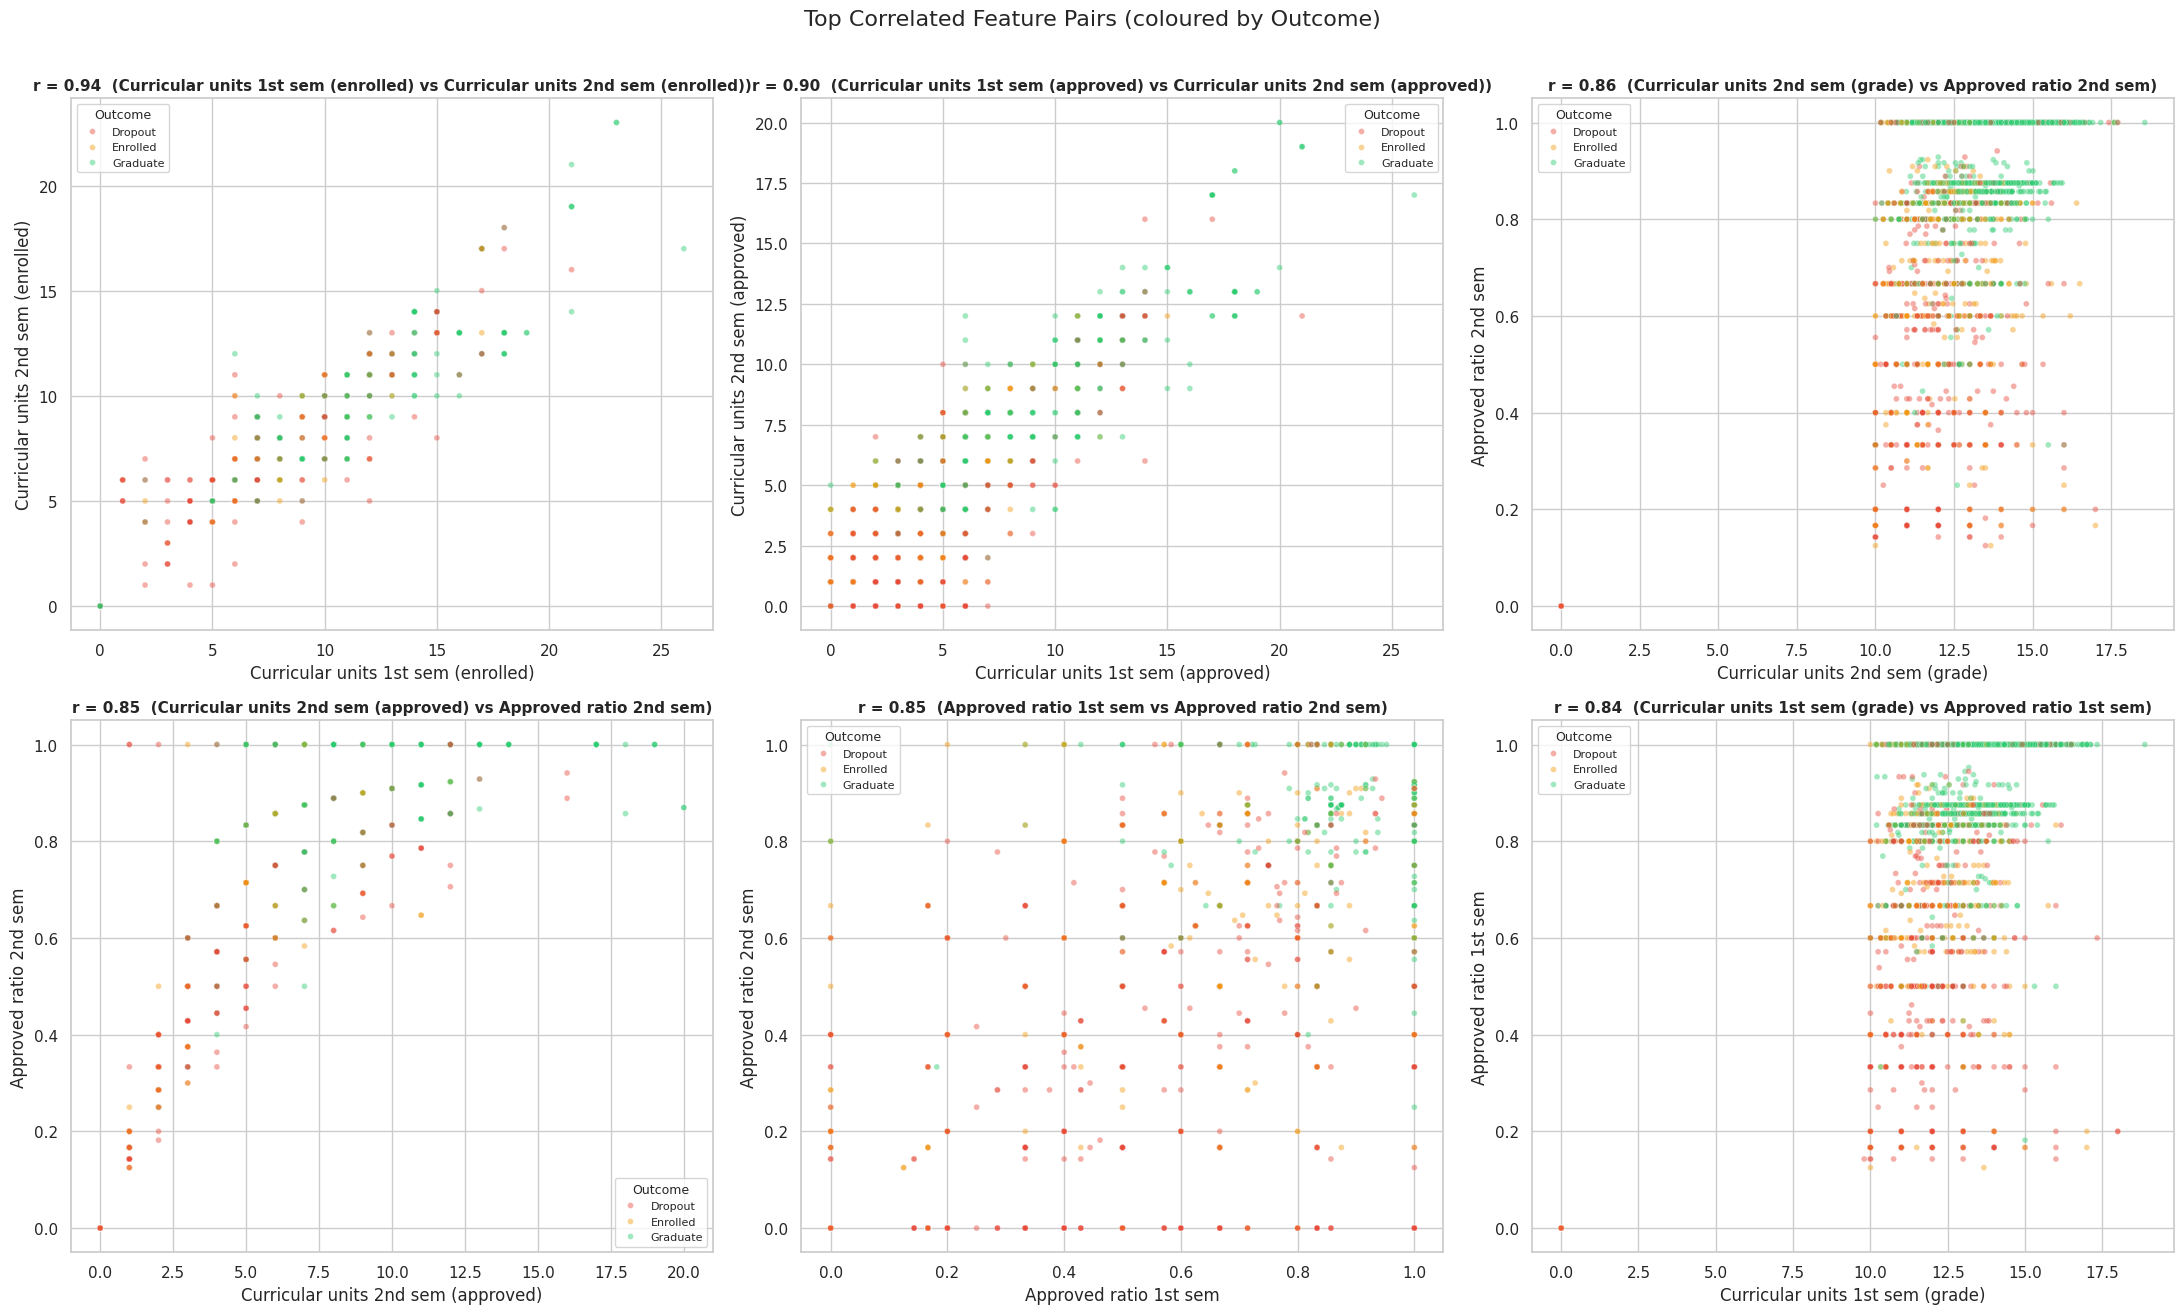

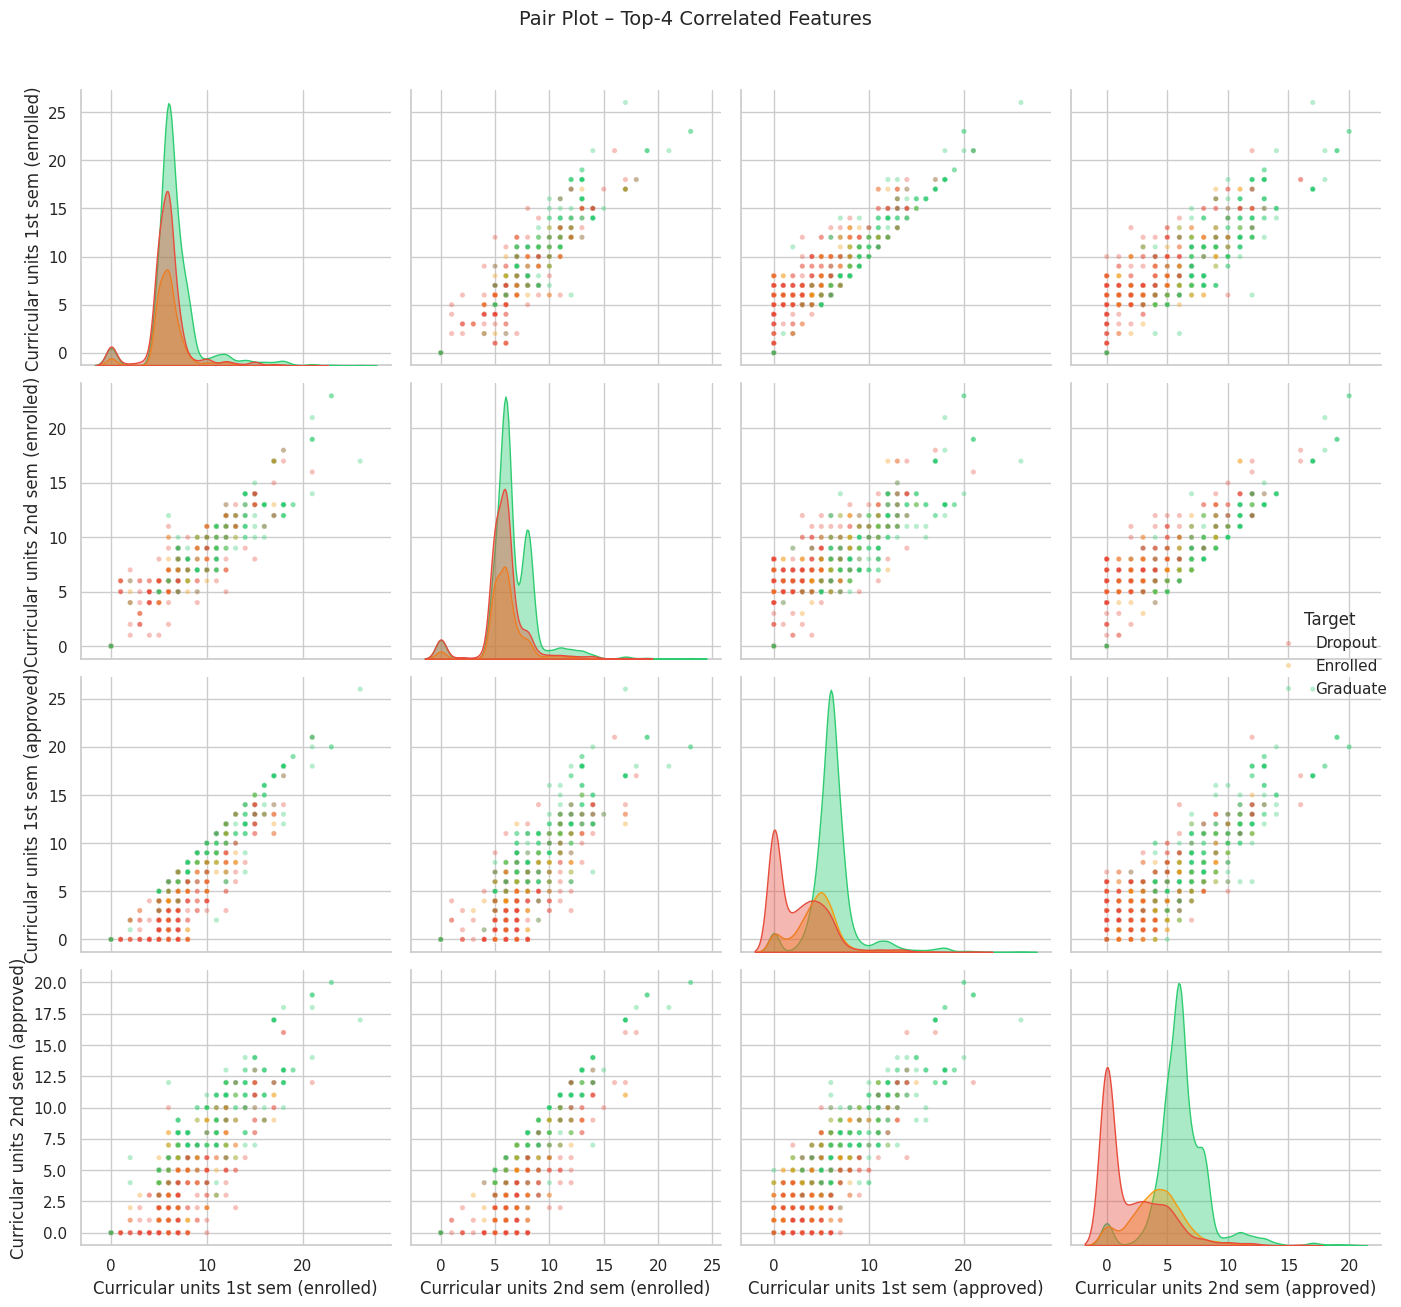

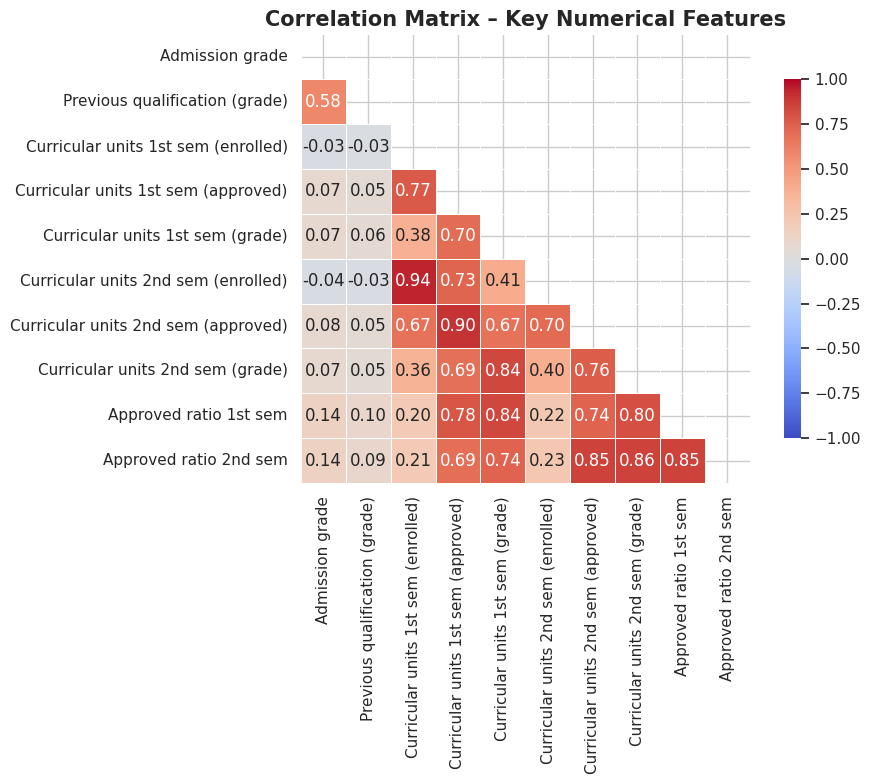

In [177]:
print("=" * 60)
print("BIVARIATE ANALYSIS – Numerical vs Numerical")
print("=" * 60)

# --- 3a. Top correlated pairs → scatter coloured by Target ---
# Build correlation on a curated numeric set
scatter_num_cols = [
    "Admission grade",
    "Previous qualification (grade)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Approved ratio 1st sem",
    "Approved ratio 2nd sem",
]
scatter_num_cols = [c for c in scatter_num_cols if c in df.columns]

corr_df = df[scatter_num_cols].corr()

# Extract the strongest absolute correlations (exclude diagonal)
corr_flat = (
    corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
           .stack().reset_index()
)
corr_flat.columns = ["feat_a", "feat_b", "corr"]
corr_flat = corr_flat.dropna().sort_values("corr", ascending=False)
top_pairs = corr_flat.head(6)

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
axes = axes.flatten()

for idx, (i, row) in enumerate(top_pairs.iterrows()):
    ax = axes[idx]
    sns.scatterplot(
        data=df, x=row["feat_a"], y=row["feat_b"],
        hue="Target", hue_order=target_order,
        palette=palette_target, alpha=0.45, s=18, ax=ax,
    )
    ax.set_title(f"r = {row['corr']:.2f}  ({row['feat_a']} vs {row['feat_b']})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel(row["feat_a"])
    ax.set_ylabel(row["feat_b"])
    ax.legend(title="Outcome", fontsize=8, title_fontsize=9)

for j in range(len(top_pairs), len(axes)):
    axes[j].axis("off")

plt.suptitle("Top Correlated Feature Pairs (coloured by Outcome)",
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# --- 3b. Pair plot for the top-4 most correlated numeric features ---
top4 = corr_flat.head(4)[["feat_a", "feat_b"]].values.flatten()
top4 = list(dict.fromkeys(top4))[:4]
g = sns.pairplot(
    df, vars=top4, hue="Target", hue_order=target_order,
    palette=palette_target, diag_kind="kde",
    plot_kws=dict(alpha=0.35, s=14),
    diag_kws=dict(fill=True, alpha=0.4),
    height=3.2,
)
g.figure.suptitle("Pair Plot – Top-4 Correlated Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# --- 3c. Enhanced correlation heatmap (replaces or augments existing) ---
fig, ax = plt.subplots(figsize=(10, 8)) # Reduced figsize
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    cbar_kws=dict(shrink=0.8),
)
ax.set_title("Correlation Matrix – Key Numerical Features",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary of Bivariate Analyses - Dropout vs Graduation Signals

### Enrollment Across Semesters
- **Correlation**: r = 0.94 (very strong).
- **Insight**: Students who enroll more in 1st sem also enroll more in 2nd sem.
- **Risk**: Low enrollment → dropout.
- **Success**: High enrollment → graduation.

### Approvals Across Semesters
- **Correlation**: r = 0.90 (very strong).
- **Insight**: Approvals are consistent across semesters.
- **Risk**: Low approvals → dropout.
- **Success**: High approvals → graduation.

### Grades Across Semesters
- **Correlation**: r = 0.84 (strong).
- **Insight**: Grades overlap across outcomes, but density differs.
- **Risk**: Zeros or low grades in either semester → dropout.
- **Success**: Consistent grades (10-20 range) → persistence/graduation.

### 1st Sem Enrolled vs Approved
- **Correlation**: r = 0.77 (strong).
- **Insight**: Efficiency matters - converting enrolled modules into approvals.
- **Risk**: Many enrolled but few approved → dropout.
- **Success**: Enrolled ≈ approved (especially 5+ modules) → graduation.

### 2nd Sem Approved vs 2nd Sem Grade
- **Correlation**: r = 0.76 (strong).
- **Insight**: Approvals drive graduation more than grades, grades plateau (10–17 range).
- **Risk**: 1–3 approvals + moderate grades → dropout.
- **Success**: 4+ approvals + sustained grades → graduation.

### 1st Sem Approved vs 2nd Sem Enrolled
- **Correlation**: r = 0.73 (strong).
- **Insight**: Approvals in sem 1 fuel progression into sem 2.
- **Risk**: 0–5 approvals + 0–10 enrollments → dropout.
- **Success**: 5–15 approvals + 5–15 enrollments → graduation.

---

## Consolidated Risk Map
- **Dropout signals**:  
  - Low enrollment (both semesters).  
  - Low approvals (especially <5).  
  - Zeros in grades or approvals.  
  - High enrollment but poor approval efficiency.  
- **Graduation signals**:  
  - High enrollment sustained across semesters.  
  - High approvals consistently (≥5 modules).  
  - Grades in 10–20 range with approvals to match.  
  - Efficiency: enrolled ≈ approved.  
  - Progression: strong sem 1 approvals → active sem 2 enrollment.

**Overall Insight**:  
Persistence and graduation are best predicted by **approval efficiency in sem 1** and **sustained approvals + active enrollment in sem 2**. Grades refine the picture but approvals are the strongest driver.

---

### Correlation Matrix – Key Academic Insights
- **Enrollment consistency**: 1st vs 2nd sem enrolled → r = 0.94 (very strong).  
- **Approval consistency**: 1st vs 2nd sem approved → r = 0.90 (very strong).  
- **Grades consistency**: 1st vs 2nd sem grades → r = 0.84 (strong).  
- **Efficiency link**: Enrolled vs approved within semesters → r ≈ 0.76–0.77 (strong).  
- **Admission grade**: Moderate link to previous qualification (r = 0.58), weaker to semester outcomes.  

**Overall Insight**: Persistence and graduation are best predicted by **enrollment and approval consistency across semesters**, while grades refine the picture and admission background plays a secondary role.


### BIVARIATE ANALYSIS – Categorical vs Categorical

BIVARIATE ANALYSIS – Categorical vs Categorical


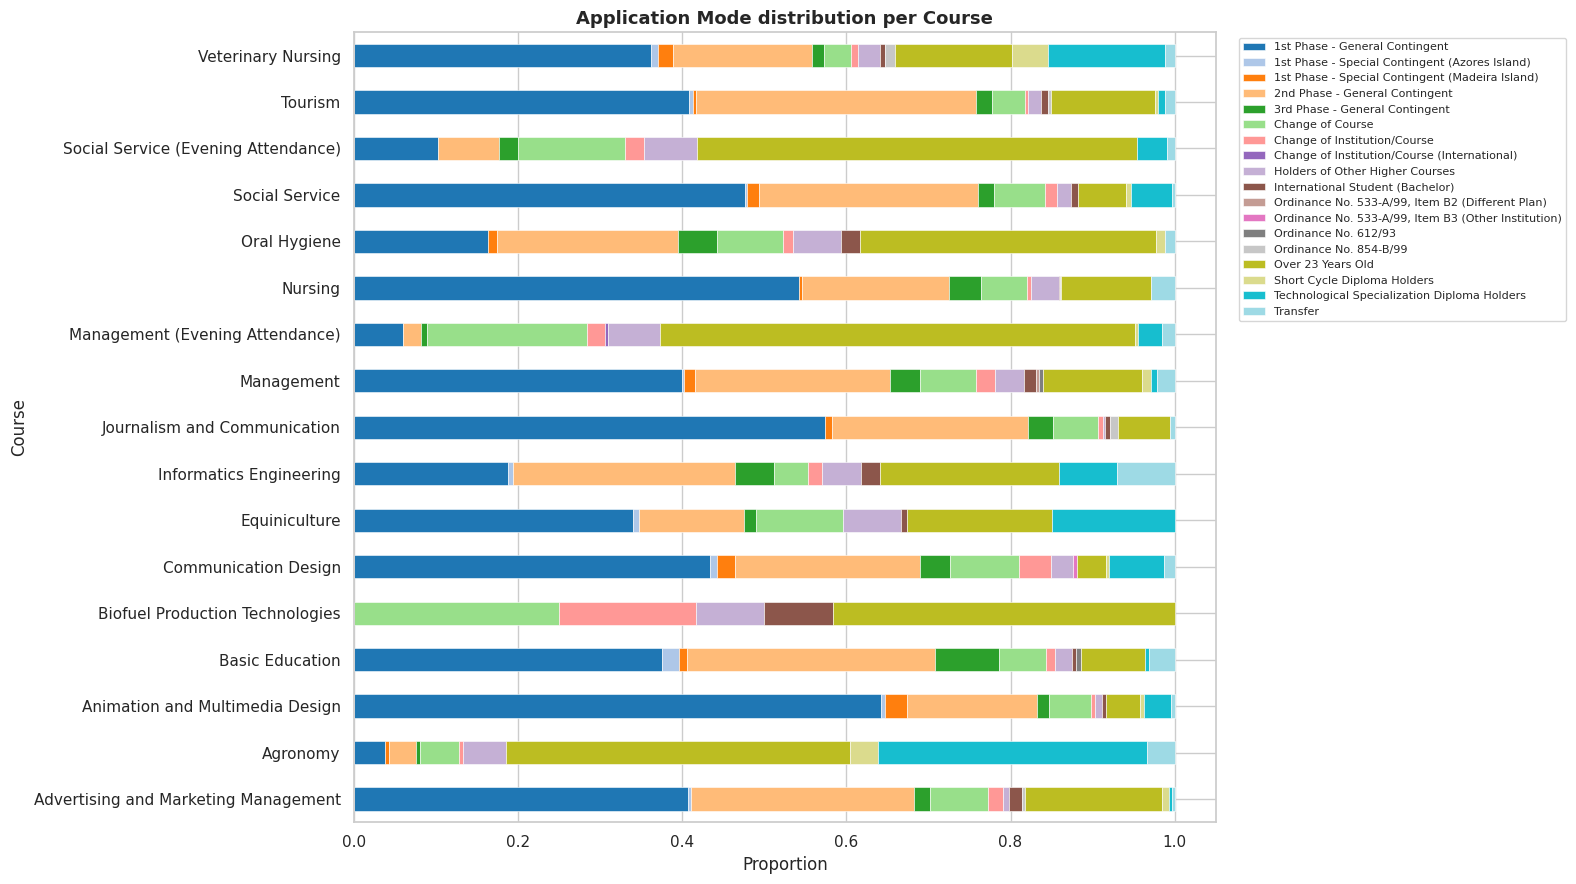

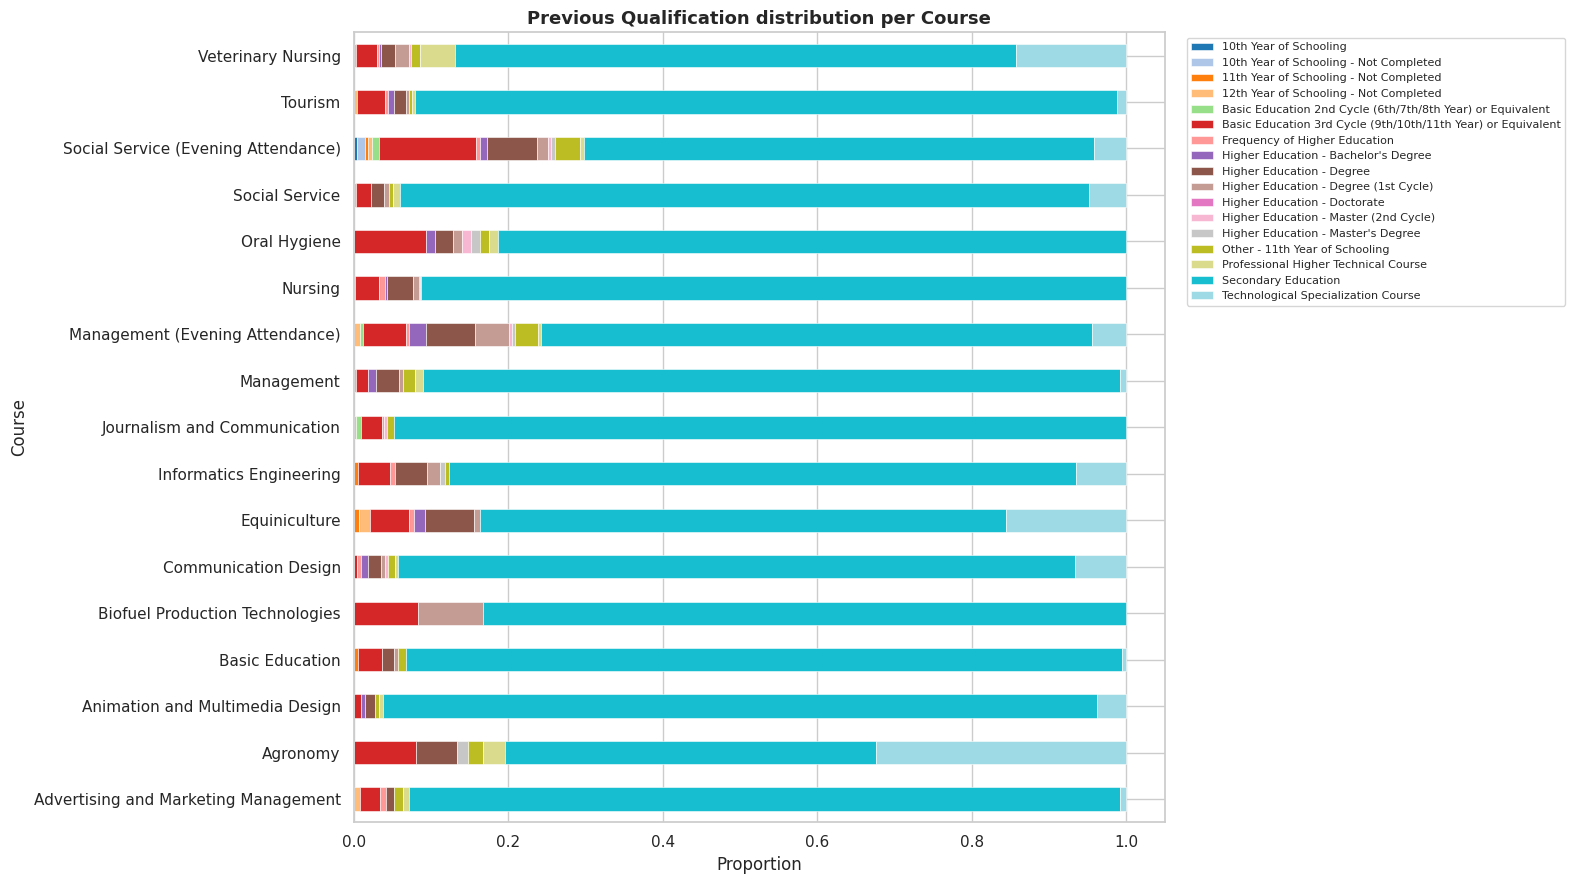

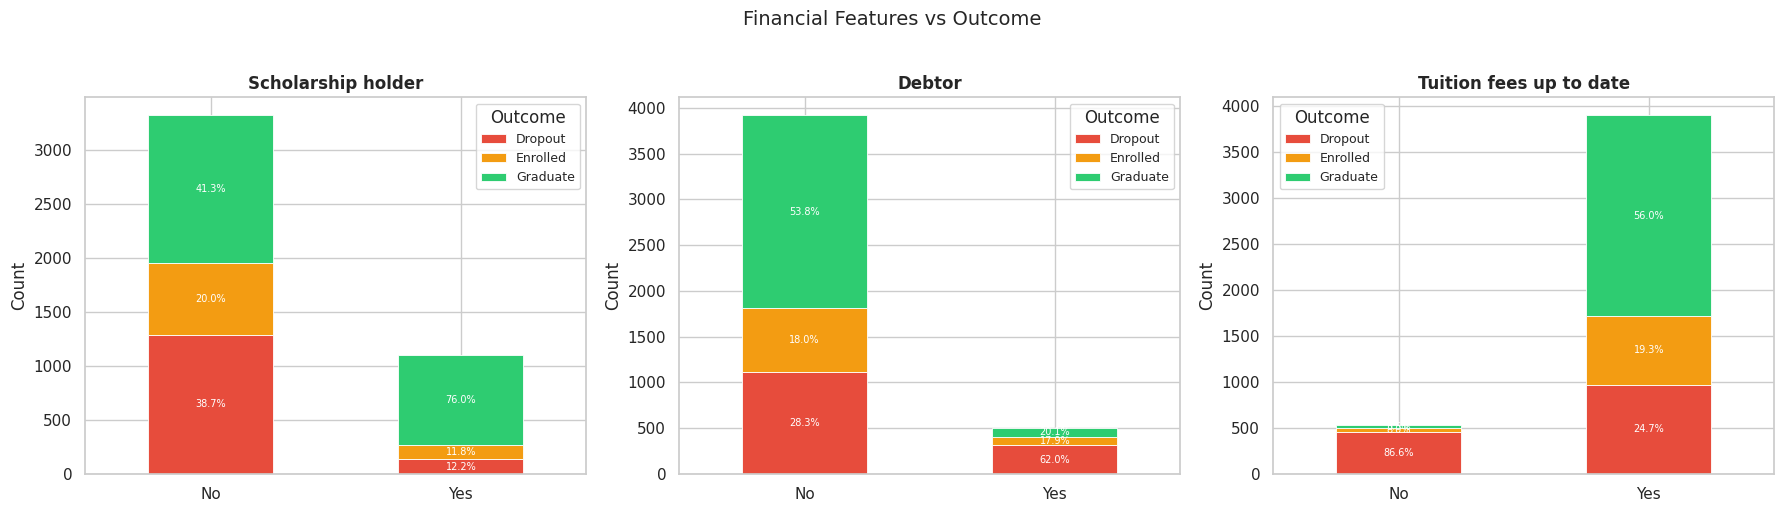

,Feature pair,χ²,p-value,dof,Significant (α=0.05)
5,Tuition fees up to date × Target,823.55,1.47e-179,2,✅
0,Course × Target,558.28,2.32e-97,32,✅
1,Application mode × Target,466.51,1.96e-77,34,✅
3,Scholarship holder × Target,409.94,9.59e-90,2,✅
4,Debtor × Target,259.33,4.86e-57,2,✅
6,Gender × Target,233.27,2.22e-51,2,✅
2,Previous qualification × Target,219.68,7.16e-30,32,✅
7,Marital status × Target,63.44,8.05e-10,10,✅
8,International × Target,1.28,5.27e-01,2,❌


In [178]:
print("=" * 60)
print("BIVARIATE ANALYSIS – Categorical vs Categorical")
print("=" * 60)

# --- 4a. Course × Application mode ---
ct_course_app = pd.crosstab(df["Course"], df["Application mode"], normalize="index")
fig, ax = plt.subplots(figsize=(16, 9))
ct_course_app.plot(kind="barh", stacked=True, ax=ax,
                   colormap="tab20", edgecolor="white", linewidth=0.4)
ax.set_title("Application Mode distribution per Course",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# --- 4b. Course × Previous qualification ---
ct_course_pq = pd.crosstab(df["Course"], df["Previous qualification"], normalize="index")
fig, ax = plt.subplots(figsize=(16, 9))
ct_course_pq.plot(kind="barh", stacked=True, ax=ax,
                  colormap="tab20", edgecolor="white", linewidth=0.4)
ax.set_title("Previous Qualification distribution per Course",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# --- 4c. Scholarship holder × Debtor × Tuition fees up to date ---
fin_cols = ["Scholarship holder", "Debtor", "Tuition fees up to date"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(fin_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df["Target"]).reindex(columns=target_order).fillna(0)
    ct_normalized = pd.crosstab(df[col], df["Target"], normalize='index').reindex(columns=target_order).fillna(0)

    # Plot stacked bar chart for counts
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[palette_target[c] for c in target_order],
            edgecolor="white", linewidth=0.6)
    ax.set_title(f"{col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.legend(title="Outcome", fontsize=9)
    ax.tick_params(axis="x", rotation=0)

    # Add proportion percentages on the bars for the normalized version
    for container_idx, container in enumerate(ax.containers): # Iterate with index
        target_label = target_order[container_idx] # Map container index to target label
        for patch in container.patches:
            x_center = patch.get_x() + patch.get_width() / 2
            y_center = patch.get_y() + patch.get_height() / 2

            category_idx = int(round(x_center)) # Robust way to get x-axis category index

            if 0 <= category_idx < len(ct_normalized.index):
                category_label = ct_normalized.index[category_idx]
                proportion = ct_normalized.loc[category_label, target_label]

                if proportion > 0.03: # Only display if big enough to be legible
                    ax.text(x_center, y_center, f'{proportion:.1%}',
                            ha='center', va='center', color='white', fontsize=7)

plt.suptitle("Financial Features vs Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 4d. Chi-Square test for key categorical pairs ---
from scipy.stats import chi2_contingency

cat_pairs = [
    ("Course", "Target"),
    ("Application mode", "Target"),
    ("Previous qualification", "Target"),
    ("Scholarship holder", "Target"),
    ("Debtor", "Target"),
    ("Tuition fees up to date", "Target"),
    ("Gender", "Target"),
    ("Marital status", "Target"),
    ("International", "Target"),
]

chi2_results = []
for feat_a, feat_b in cat_pairs:
    ct = pd.crosstab(df[feat_a], df[feat_b])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        "Feature pair": f"{feat_a} × {feat_b}",
        "χ²": round(chi2, 2),
        "p-value": f"{p:.2e}",
        "dof": dof,
        "Significant (α=0.05)": "✅" if p < 0.05 else "❌",
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("χ²", ascending=False)
display(chi2_df)

### Application Mode Distribution per Course
- **General contingent**: Dominates most programs (e.g., Nursing, Informatics Engineering, Communication Design, Journalism).  
- **Alternative modes**: More dominant in **Agronomy, Biofuel Production Technologies, Management (Evening Attendance), Social Service (Evening Attendance)**.  
- **Evening programs**: Attract higher shares of **Over 23, Change of Course** applicants.  
- **Specialized programs**: Agronomy and Biofuel Production rely more on non-general pathways.  

**Overall Insight**: While all courses show some diversity in application modes, the **general contingent is the main entry route** for most programs. Only a few (Agronomy, Biofuel Production, and evening tracks) show stronger reliance on alternative pathways.

---

### Previous Qualification Distribution per Course
- **Secondary Education**: Dominates all courses.  
- **Technological Specialization Course**: Significant in Agronomy, Equiniculture, Veterinary Nursing.  
- **Basic Education 3rd Cycle (9th/10th/11th Year or equivalent)**: Significant in Social Service (Evening Attendance), Oral Hygiene, Biofuel Production Tech, Agronomy.  
- **Higher Education – Degree**: Significant in Social Service (Evening Attendance), Equiniculture, Management (Evening Attendance), Agronomy.  

**Overall Insight**: Secondary education is the main entry background across all programs, but **TSC, Basic Education 3rd Cycle, and Higher Education pathways** play important roles in specific courses — especially evening tracks and niche programs.

---
### Financial Features vs Outcome

#### Scholarship Holder
- **Graduates**: 76% with scholarship vs 41% without.
- **Dropouts**: 12% with scholarship vs 39% without.
- **Insight**: Scholarships strongly protect against dropout and boost graduation.

#### Debtor Status
- **Dropouts**: 62% debtors vs 28% non‑debtors.
- **Graduates**: 20% debtors vs 54% non‑debtors.
- **Insight**: Debt is a major risk factor - strongly linked to dropout.

#### Tuition Fees Up to Date
- **Dropouts**: 87% not up to date vs 25% up to date.
- **Graduates**: 6% not up to date vs 56% up to date.
- **Insight**: Fee payment status is the most decisive predictor - unpaid tuition almost guarantees dropout.


**Overall Insight**:  
Financial stability is the strongest driver of persistence and graduation.  
- **Protective factors**: Scholarships, fee payment up to date.  
- **Risk factors**: Debt, unpaid tuition.  

---

### Chi-Square Test Results - Overall Insight

- **Most decisive predictors**: Financial features - tuition fee status, scholarships, and debt - are the strongest signals of dropout vs graduation.  
- **Strong academic/contextual predictors**: Course choice and application mode also significantly shape outcomes.  
- **Moderate demographic predictors**: Gender, marital status, and previous qualification show meaningful but less dominant effects.  
- **Non-significant factor**: International status has no measurable impact on outcomes.  

**Summary**: Persistence and graduation are primarily driven by **financial stability**, reinforced by **course/admission pathways**, with demographics and prior qualifications playing secondary roles.

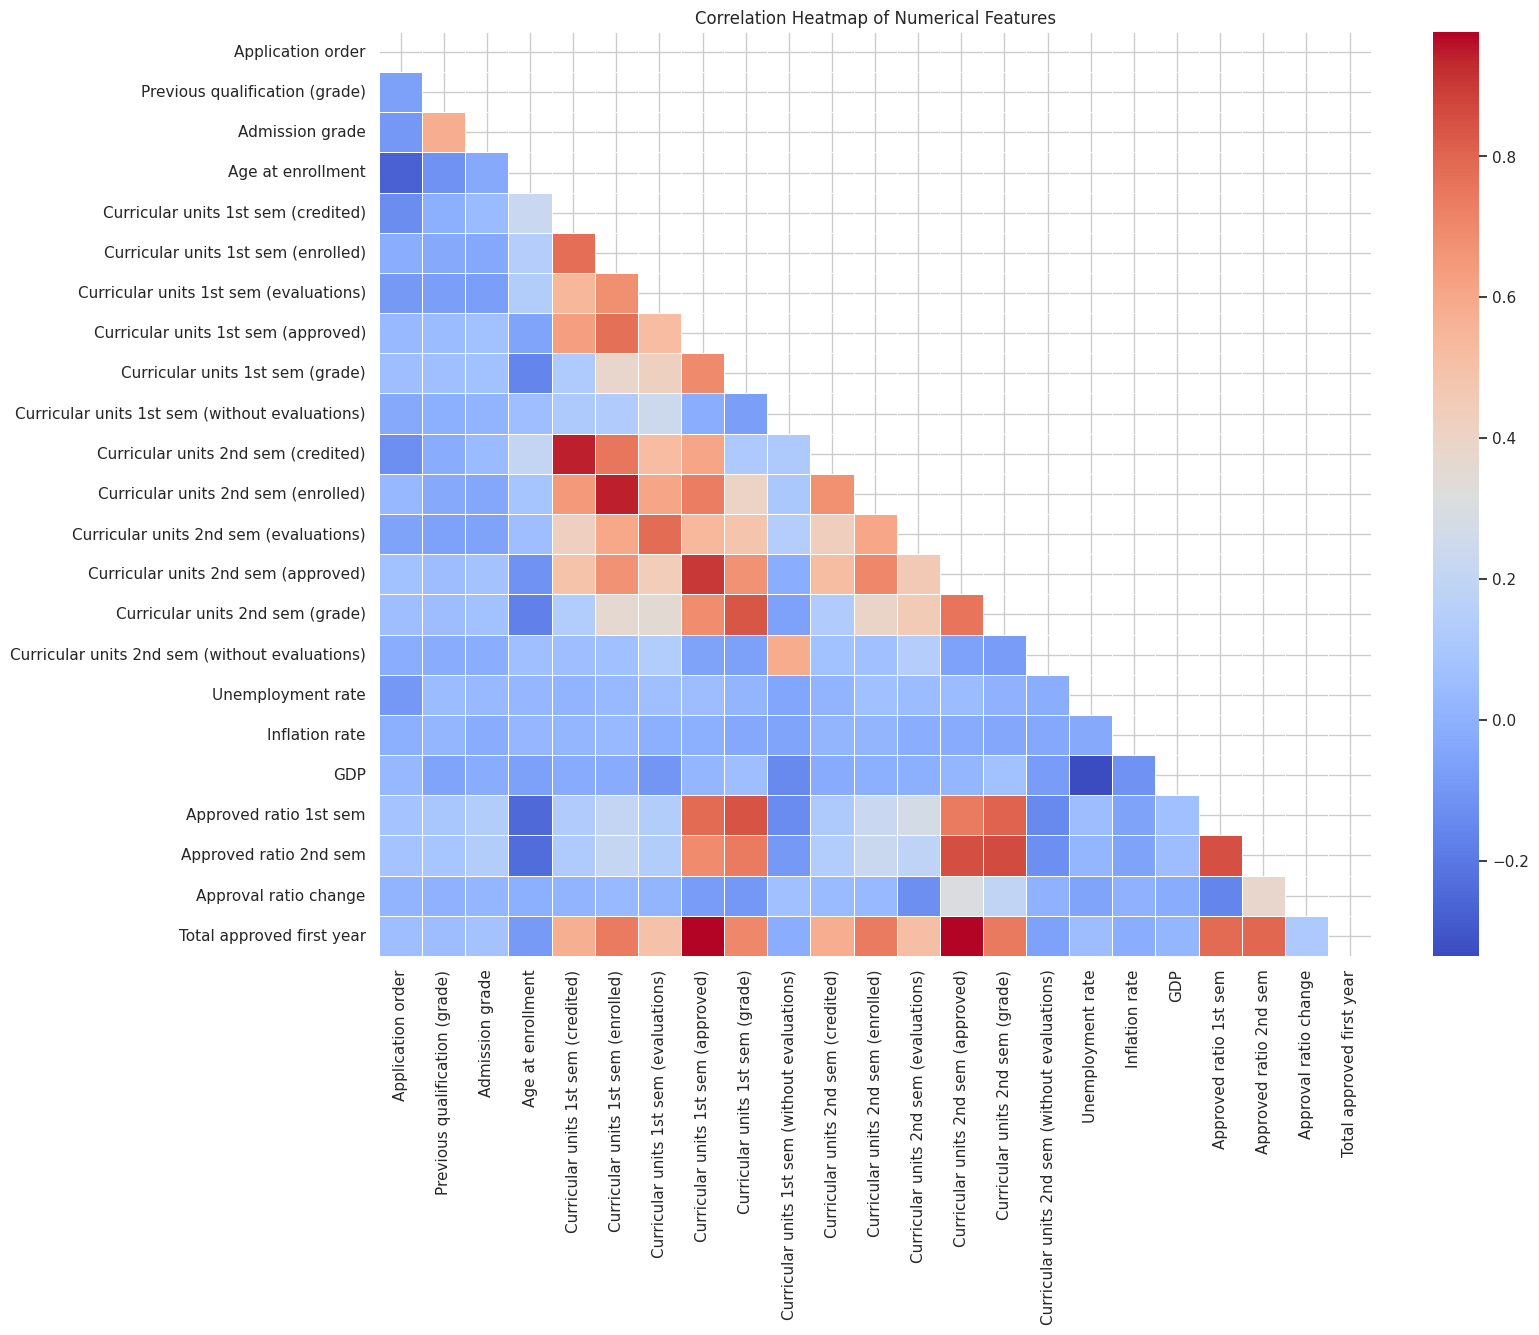

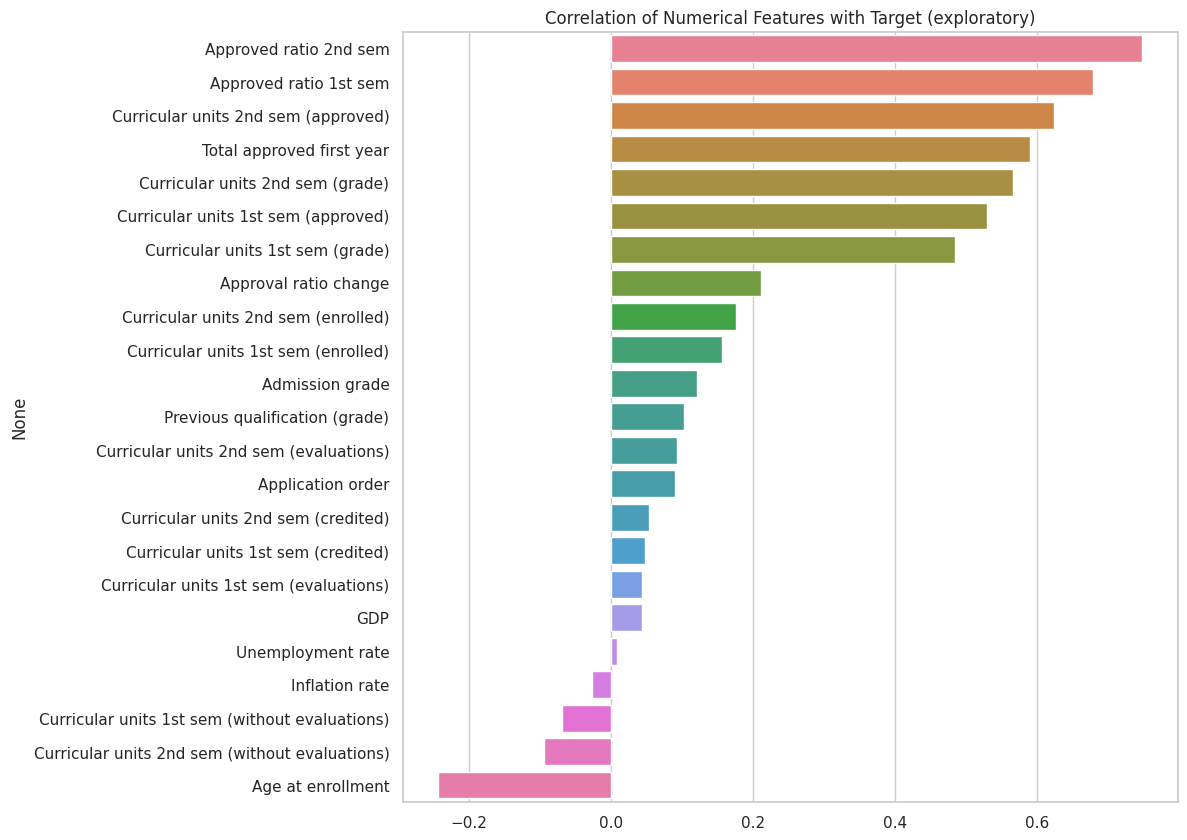

In [179]:
# Correlation heatmap (numerical)
plt.figure(figsize=(16, 12))
corr = df[list(X_num)].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Feature-vs-target correlation
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
target_corr = df[list(X_num)].corrwith(df['Target'].map(target_map)).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, legend=False)
plt.title('Correlation of Numerical Features with Target (exploratory)')
plt.show()

# 13. Early Feature Engineering

In [180]:
# Application order audit — is a 'first choice' flag usable?
print(df['Application order'].value_counts().sort_index())

Application order
0       1
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
Name: count, dtype: Int64


**Finding:** `Application order == 0` occurs only **once** in 4,424 rows, so a binary
"First choice" flag is degenerate (≈constant) and unusable.

**Decision:** keep `Application order` as an *ordinal* feature, do **not** create the
binary flag.

In [181]:
# Zero-enrollment students (undefined ratios)
zero_enrollment = ((df['Curricular units 1st sem (enrolled)'] == 0) &
                   (df['Curricular units 2nd sem (enrolled)'] == 0))
df['No enrollment both semesters'] = zero_enrollment.astype(int)

print('Zero-enrollment students:', int(zero_enrollment.sum()))
display(pd.crosstab(df['No enrollment both semesters'], df['Target'],
                    normalize='index').round(3))

Zero-enrollment students: 180


Target,Dropout,Enrolled,Graduate
No enrollment both semesters,,,
0,0.317,0.180,0.503
1,0.428,0.156,0.417


**Investigation Result:**
*   There are 180 students with zero enrollment in both semesters.
*   For these students, both their enrolled and approved units were 0 in both semesters, leading to undefined (NaN) approval ratios.
*   Their outcome distribution is: 42.8% Dropout, 15.6% Enrolled, and 41.7% Graduate.
*   Compared to the general student population (approximately 32.1% Dropout and 49.9% Graduate), this group shows a higher dropout rate and a lower graduation rate.
*   This suggests that the 'No enrollment both semesters' flag *is* discriminative.

**Decision:** We will keep these rows, retain the NaN values for the ratios, and keep the 'No enrollment both semesters' flag as a feature due to its discriminative power.

In [182]:
# Macro variables: individual features or cohort (year) proxies?
macro = df[['Unemployment rate', 'Inflation rate', 'GDP']]
print('Unique values per macro variable:\n', macro.nunique())
display(macro.drop_duplicates())

Unique values per macro variable:
 Unemployment rate    10
Inflation rate        9
GDP                  10
dtype: int64


,Unemployment rate,Inflation rate,GDP
0,10.8,1.4,1.74
1,13.9,-0.3,0.79
3,9.4,-0.8,-3.12
5,16.2,0.3,-0.92
6,15.5,2.8,-4.06
9,8.9,1.4,3.51
11,12.7,3.7,-1.70
20,11.1,0.6,2.02
25,7.6,2.6,0.32
33,12.4,0.5,1.79


* Macro variables have very few unique combinations → they encode the **enrollment
  cohort/year**, not individual students. Treat as cohort indicators and use
  time-aware validation in Notebook 04.

## 14. Basic Statistical Testing (Exploratory)
Kruskal–Wallis + Dunn's (Holm) + ε² effect size, refactored into one reusable helper.

--- Approved ratio 1st sem ---  H=1941.08, p=0.000e+00, epsilon²=0.457


,Dropout,Enrolled,Graduate
Dropout,1.0,0.0,0.0
Enrolled,0.0,1.0,0.0
Graduate,0.0,0.0,1.0


--- Approved ratio 2nd sem ---  H=2324.52, p=0.000e+00, epsilon²=0.548


,Dropout,Enrolled,Graduate
Dropout,1.0,0.0,0.0
Enrolled,0.0,1.0,0.0
Graduate,0.0,0.0,1.0


--- Approval ratio change ---  H=178.06, p=2.159e-39, epsilon²=0.042


,Dropout,Enrolled,Graduate
Dropout,1.0,0.0,0.0
Enrolled,0.0,1.0,0.0
Graduate,0.0,0.0,1.0


--- Total approved first year ---  H=1824.15, p=0.000e+00, epsilon²=0.412


,Dropout,Enrolled,Graduate
Dropout,1.0,0.0,0.0
Enrolled,0.0,1.0,0.0
Graduate,0.0,0.0,1.0


,Approved ratio 1st sem,Approved ratio 2nd sem,Approval ratio change
Target,,,
Dropout,0.406,0.310,-0.096
Enrolled,0.714,0.673,-0.040
Graduate,0.935,0.932,-0.003


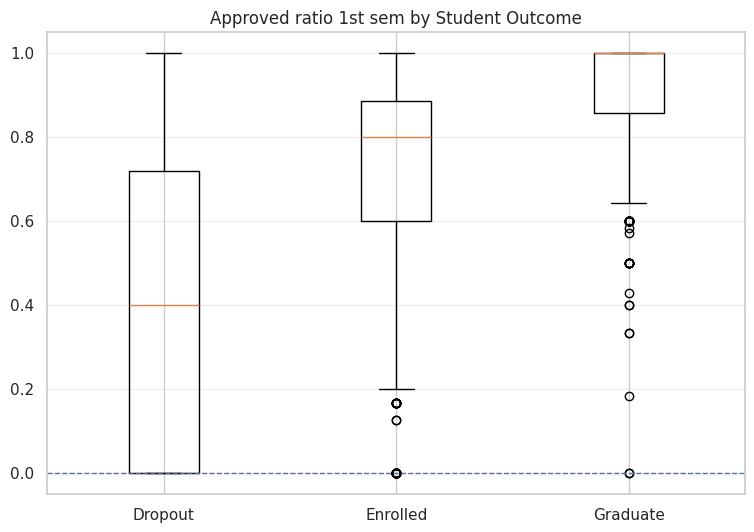

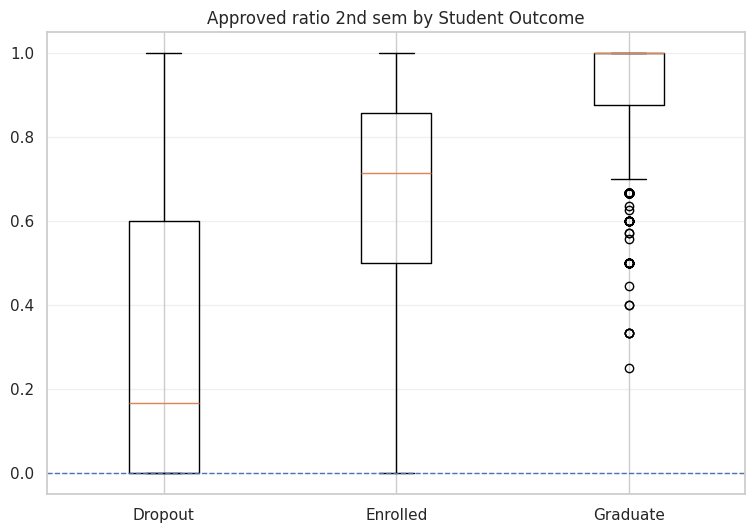

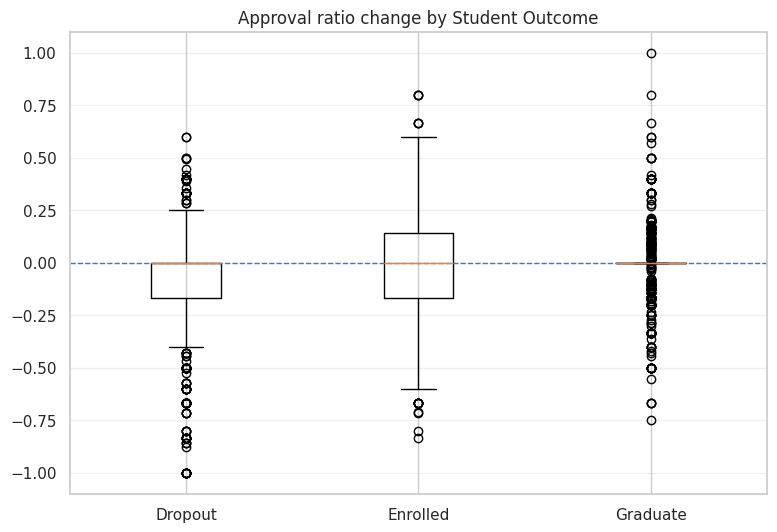

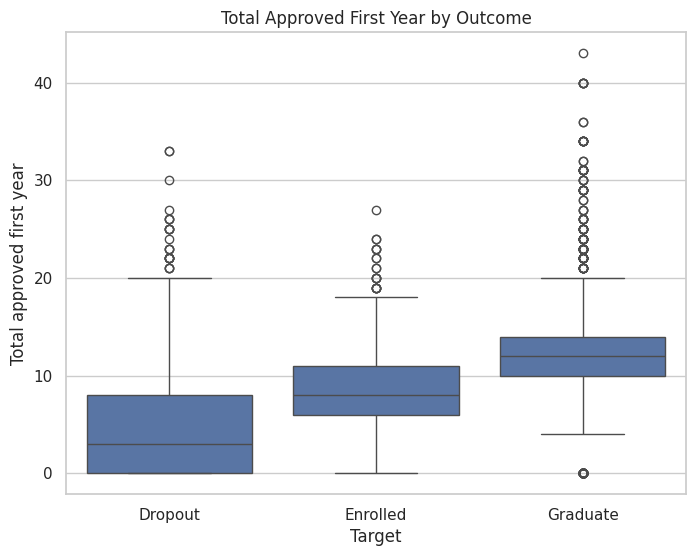

In [183]:
order = ['Dropout', 'Enrolled', 'Graduate']

def epsilon_squared(H, groups):
    n = sum(len(g) for g in groups)
    k = len(groups)
    return (H - k + 1) / (n - k)

def compare_groups(data, value_col):
    d = data.dropna(subset=[value_col])
    groups = [d.loc[d['Target'] == t, value_col] for t in order]
    H, p = kruskal(*groups)
    print(f'--- {value_col} ---  H={H:.2f}, p={p:.3e}, epsilon²={epsilon_squared(H, groups):.3f}')
    display(sp.posthoc_dunn(d, val_col=value_col, group_col='Target', p_adjust='holm').round(3))

ratio_df = df.dropna(subset=['Approved ratio 1st sem', 'Approved ratio 2nd sem'])

for col in ['Approved ratio 1st sem', 'Approved ratio 2nd sem', 'Approval ratio change']:
    compare_groups(ratio_df, col)
compare_groups(df, 'Total approved first year')

# Group means for interpretation
display(ratio_df.groupby('Target', observed=True)
        [['Approved ratio 1st sem', 'Approved ratio 2nd sem', 'Approval ratio change']]
        .mean().round(3))

# Boxplots
for col in ['Approved ratio 1st sem', 'Approved ratio 2nd sem', 'Approval ratio change']:
    plt.figure(figsize=(9, 6))
    plt.boxplot([ratio_df.loc[ratio_df['Target'] == t, col] for t in order],
                tick_labels=order)
    plt.axhline(0, ls='--', lw=1)
    plt.title(f'{col} by Student Outcome')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Target', y='Total approved first year')
plt.title('Total Approved First Year by Outcome')
plt.show()

### FEATURE IMPORTANCE PREVIEW (bridge to feature engineering)

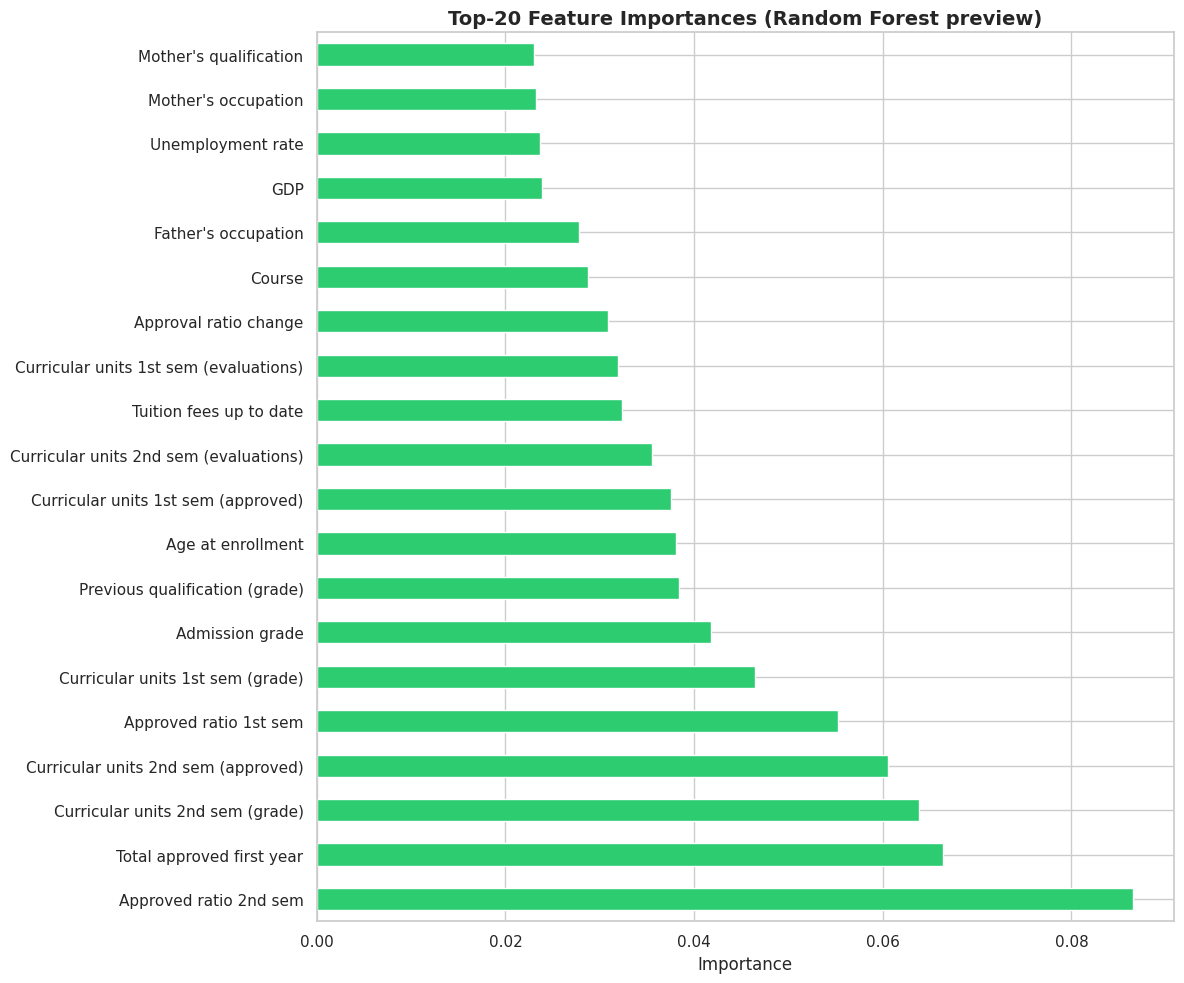

,importance
Approved ratio 2nd sem,0.0865
Total approved first year,0.0664
Curricular units 2nd sem (grade),0.0639
Curricular units 2nd sem (approved),0.0605
Approved ratio 1st sem,0.0552
Curricular units 1st sem (grade),0.0465
Admission grade,0.0418
Previous qualification (grade),0.0384
Age at enrollment,0.0381
Curricular units 1st sem (approved),0.0375


In [184]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Prepare a quick numeric view (no leakage – just exploratory)
df_model = df.copy()

# Encode categoricals with ordinal encoding for the quick RF preview
cat_cols_model = df_model.select_dtypes(include=["object", "category"]).columns.tolist()
if "Target" in cat_cols_model:
    cat_cols_model.remove("Target")

le_target = LabelEncoder()
df_model["Target_enc"] = le_target.fit_transform(df_model["Target"])

oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_model[cat_cols_model] = oe.fit_transform(df_model[cat_cols_model])

feature_cols = [c for c in df_model.columns
                if c not in ["Target", "Target_enc"]]

rf = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1,
    class_weight="balanced",
)
rf.fit(df_model[feature_cols], df_model["Target_enc"])

feat_imp = (
    pd.Series(rf.feature_importances_, index=feature_cols)
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 10))
feat_imp.head(20).plot(kind="barh", ax=ax, color="#2ecc71", edgecolor="white")
ax.set_title("Top-20 Feature Importances (Random Forest preview)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

display(feat_imp.head(20).to_frame("importance").round(4))

## 15. Insight Summary & Handoff

**Data quality**
- 4,424 × 37; 0 missing; 0 duplicates; all ranges valid; approved ≤ enrolled always.
- Decoding: 0 unmapped codes, 0 new nulls.

**Key insights**
1. Target: Graduate 49.9% / Dropout 32.1% / Enrolled 17.9% → moderate imbalance;
   use stratified splits and macro-averaged metrics (Notebook 04).
2. Approval ratios strongly separate outcomes (ε² ≈ 0.46 1st sem, 0.55 2nd sem; all Dunn pairs significant). Mean approved ratios: Dropouts decline 40.6% → 31.0%; Enrolled 71.4% → 67.3%; Graduates stable ≈ 93.5% → 93.2%.
3. Total approved first year: ε² ≈ 0.41; medians Dropout = 3, Enrolled = 8, Graduate = 12 → candidate early-warning rule "≤ 3 approved units" to validate in 04.
4. 180 zero-enrollment students kept with a flag; ratios left as NaN.
5. `Application order` binary flag abandoned (degenerate); keep ordinal.
6. `International` ≡ non-Portuguese → drop one in Notebook 02.
7. Macro variables are cohort proxies → time-aware validation in Notebook 04.

**Handoff:** clean dataset exported below → consumed by `02_feature_engineering.ipynb`.

In [185]:
engineered = ['Approved ratio 1st sem', 'Approved ratio 2nd sem',
              'Approval ratio change', 'Total approved first year',
              'No enrollment both semesters']
assert df.shape == (4424, 42) and all(c in df.columns for c in engineered)
assert 'First choice' not in df.columns
print('✅ Manifest OK —', df.shape)

✅ Manifest OK — (4424, 42)


In [186]:
import os
OUT_PATH = ('/content/drive/MyDrive/std_dropout_prediction_project/'
            'data/processed/student_dropout_clean.csv')
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
df.to_csv(OUT_PATH, index=False)
print('Saved clean dataset:', df.shape)

Saved clean dataset: (4424, 42)
